# Classificação de dígitos manuscritos

Mini-projeto avaliativo — Módulo 02.

**Estado:** análise exploratória, divisão estratificada e normalização concluídas. KNN, Random Forest, MLP e CNN comparados na validação, com diagramas das redes. Calibração e avaliação no teste concluídas, incluindo matrizes de confusão e bootstrap. Experimento com classes ocultadas e avaliação de imagens próprias concluídos, com registro das previsões e probabilidades das trinta imagens.

## 1. Configuração do ambiente

In [1]:
import os
import sys
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from time import perf_counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
# Configure antes de importar o TensorFlow; use um kernel reiniciado.
# Reduz os logs nativos da biblioteca; exceções Python permanecem visíveis.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
import visualkeras
from PIL import ImageFont
from matplotlib import font_manager
from IPython.display import display
import json
from scipy.optimize import minimize_scalar
from scipy.special import logsumexp, softmax
from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report, log_loss
from PIL import Image, ImageOps
from scipy.ndimage import gaussian_filter, label, binary_dilation, center_of_mass, shift

In [2]:
RANDOM_STATE = 42
CACHE_DIR = Path("data/cache")
FIGURES_DIR = Path("reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

### Verificação

A execução deve utilizar Python 3.12 no ambiente virtual do projeto.

In [3]:
print(f"Python: {sys.version.split()[0]}")
print(f"Ambiente virtual ativo: {sys.prefix != sys.base_prefix}")

bibliotecas = ["numpy", "pandas", "matplotlib", "scikit-learn", "ipykernel", "tensorflow", "keras", "visualkeras"]
pd.DataFrame({
    "Biblioteca": bibliotecas,
    "Versão": [version(nome) for nome in bibliotecas],
})

Python: 3.12.13
Ambiente virtual ativo: True


,Biblioteca,Versão
0,numpy,2.5.3
1,pandas,3.0.5
2,matplotlib,3.11.1
3,scikit-learn,1.9.0
4,ipykernel,7.3.0
5,tensorflow,2.21.0
6,keras,3.15.1
7,visualkeras,0.2.0


## 2. Carregamento e análise exploratória — Fase 1

Fonte: [MNIST no OpenML, conjunto 554](https://www.openml.org/d/554), `mnist_784`, versão 1. As verificações desta etapa descrevem a base integral; não são medidas de desempenho de um modelo.

In [4]:
mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False,
    parser="auto",
    data_home=str(CACHE_DIR),
)

X = mnist.data
y = mnist.target.astype(np.uint8)

print("Dimensões de X:", X.shape)
print("Dimensões de y:", y.shape)

Dimensões de X: (70000, 784)
Dimensões de y: (70000,)


### Estrutura e integridade

In [5]:
assert X.shape == (70_000, 784)
assert y.shape == (70_000,)
assert np.array_equal(np.unique(y), np.arange(10))
assert np.isfinite(X).all()
assert X.min() >= 0 and X.max() <= 255

pd.Series({
    "Imagens": X.shape[0],
    "Pixels por imagem": X.shape[1],
    "Tipo dos pixels": str(X.dtype),
    "Tipo dos rótulos": str(y.dtype),
    "Menor intensidade": X.min(),
    "Maior intensidade": X.max(),
    "Valores ausentes em X": int(np.isnan(X).sum()),
}, name="Diagnóstico").to_frame()

,Diagnóstico
Imagens,70000
Pixels por imagem,784
Tipo dos pixels,int64
Tipo dos rótulos,uint8
Menor intensidade,0
Maior intensidade,255
Valores ausentes em X,0


### Distribuição dos dígitos

In [6]:
contagens = pd.Series(y).value_counts().sort_index()
distribuicao = pd.DataFrame({
    "Quantidade": contagens,
    "Percentual (%)": contagens / len(y) * 100,
})
distribuicao.index.name = "Dígito"

assert distribuicao["Quantidade"].sum() == len(y)
assert np.isclose(distribuicao["Percentual (%)"].sum(), 100)
distribuicao.round(2)

,Quantidade,Percentual (%)
Dígito,,
0,6903,9.86
1,7877,11.25
2,6990,9.99
3,7141,10.20
4,6824,9.75
5,6313,9.02
6,6876,9.82
7,7293,10.42
8,6825,9.75


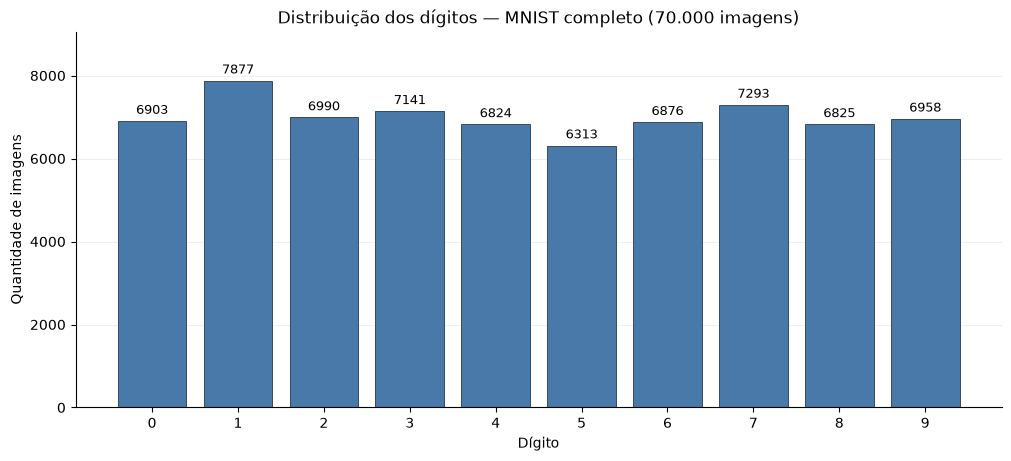

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
barras = ax.bar(contagens.index, contagens.values, color="#4879A8", edgecolor="#26384A", linewidth=0.6)
ax.bar_label(barras, padding=3, fontsize=9)
ax.set(title="Distribuição dos dígitos — MNIST completo (70.000 imagens)",
       xlabel="Dígito", ylabel="Quantidade de imagens",
       xticks=np.arange(10), ylim=(0, contagens.max() * 1.15))
ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.2)
fig.savefig(FIGURES_DIR / "distribuicao_classes.png", dpi=150)
plt.show()

### Exemplos de cada classe

A grade mostra a primeira ocorrência de cada dígito na base, com escala de intensidade idêntica em todos os painéis.

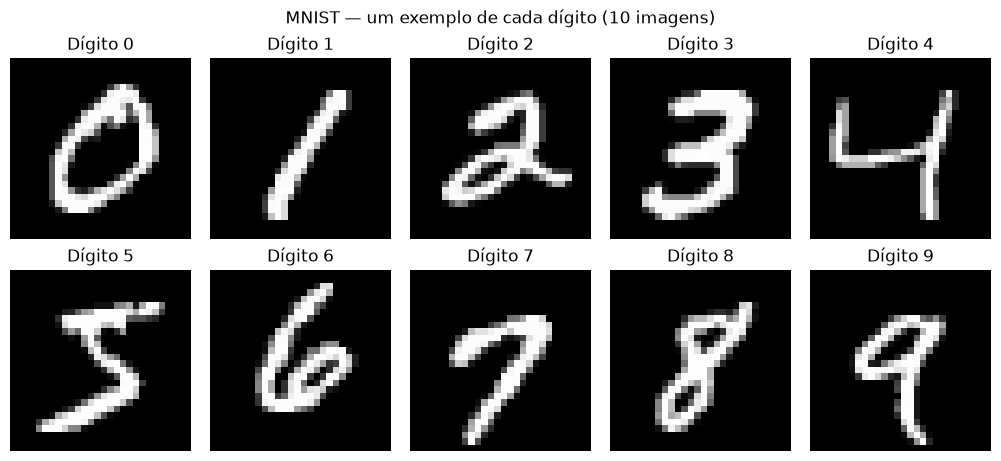

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5), layout="constrained")

for digito, ax in zip(range(10), axes.flat):
    indice = np.flatnonzero(y == digito)[0]
    ax.imshow(X[indice].reshape(28, 28), cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ax.set_title(f"Dígito {y[indice]}")
    ax.axis("off")

fig.suptitle("MNIST — um exemplo de cada dígito (10 imagens)")
fig.savefig(FIGURES_DIR / "exemplos_digitos.png", dpi=150)
plt.show()

### Imagem e representação vetorial

Cada imagem contém 28 × 28 = 784 intensidades: 0 indica preto, 255 indica branco e os valores intermediários representam tons de cinza. O OpenML já fornece cada imagem achatada em uma linha de `X`. A operação `reshape(28, 28)` recupera a disposição bidimensional preservando a ordem dos pixels.

Forma do vetor: (784,)
Forma da imagem: (28, 28)
A transformação preservou todos os pixels: True


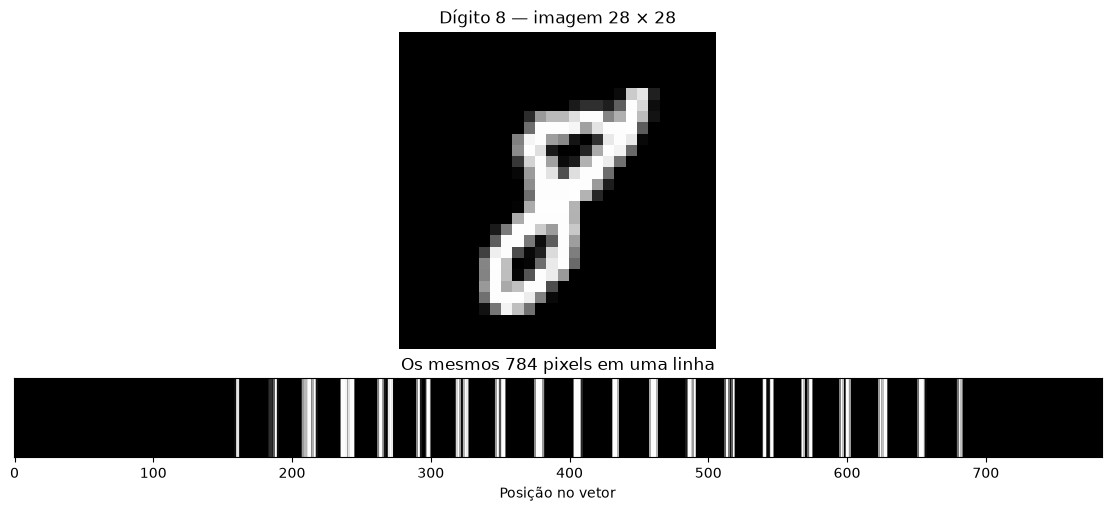

In [9]:
indice_exemplo = np.flatnonzero(y == 8)[0]
vetor = X[indice_exemplo]
imagem = vetor.reshape(28, 28)

assert np.array_equal(imagem.reshape(-1), vetor)
print("Forma do vetor:", vetor.shape)
print("Forma da imagem:", imagem.shape)
print("A transformação preservou todos os pixels:", np.array_equal(imagem.reshape(-1), vetor))

fig, axes = plt.subplots(2, 1, figsize=(11, 5), height_ratios=[4, 1], layout="constrained")
axes[0].imshow(imagem, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
axes[0].set_title(f"Dígito {y[indice_exemplo]} — imagem 28 × 28")
axes[0].axis("off")
axes[1].imshow(vetor.reshape(1, 784), cmap="gray", vmin=0, vmax=255, aspect="auto", interpolation="nearest")
axes[1].set(title="Os mesmos 784 pixels em uma linha", xlabel="Posição no vetor", yticks=[])
fig.savefig(FIGURES_DIR / "imagem_e_vetor.png", dpi=150)
plt.show()

### Síntese da análise exploratória

A base contém 70.000 imagens, com 784 intensidades inteiras entre 0 e 255 por imagem e nenhum valor ausente em `X`. As dez classes estão presentes e têm frequências próximas, mas não iguais: o dígito 1 é o mais frequente (7.877; 11,25%) e o 5 é o menos frequente (6.313; 9,02%). A transformação entre vetor e imagem preservou os pixels. Esses resultados descrevem os dados; a avaliação preditiva será realizada após a divisão em conjuntos independentes.

## 3. Divisão dos dados e normalização — Fase 2

Adotamos uma divisão aleatória estratificada das 70.000 imagens do OpenML: **60% treino, 10% validação, 10% calibração e 20% teste**, com semente 42. Esse protocolo é próprio do projeto e não corresponde à divisão oficial do MNIST em 60.000/10.000 imagens.

O treino ajustará os modelos; a validação selecionará configurações pelo F1 ponderado; a calibração será reservada para ajustar as probabilidades do modelo escolhido; o teste fornecerá a avaliação final. As mesmas partições serão usadas nas comparações. Nenhuma escolha de modelo deve usar os resultados do teste.

A estratificação deve preservar aproximadamente a frequência de cada dígito. Dividimos os índices das linhas para manter a correspondência entre imagens e rótulos e verificar cobertura e ausência de sobreposição.

In [10]:
indices = np.arange(len(y))
indices_restantes, indices_teste = train_test_split(
    indices, test_size=14_000, stratify=y, random_state=RANDOM_STATE,
)
indices_treino, indices_reserva = train_test_split(
    indices_restantes, test_size=14_000,
    stratify=y[indices_restantes], random_state=RANDOM_STATE,
)
indices_validacao, indices_calibracao = train_test_split(
    indices_reserva, test_size=7_000,
    stratify=y[indices_reserva], random_state=RANDOM_STATE,
)

particoes = {
    "Treino": indices_treino,
    "Validação": indices_validacao,
    "Calibração": indices_calibracao,
    "Teste": indices_teste,
}
indices_reunidos = np.concatenate(list(particoes.values()))
assert np.array_equal(np.sort(indices_reunidos), indices)
assert [len(idx) for idx in particoes.values()] == [42_000, 7_000, 7_000, 14_000]

pd.DataFrame({
    "Imagens": {nome: len(idx) for nome, idx in particoes.items()},
    "Percentual (%)": {nome: len(idx) / len(y) * 100 for nome, idx in particoes.items()},
})

,Imagens,Percentual (%)
Treino,42000,60.0
Validação,7000,10.0
Calibração,7000,10.0
Teste,14000,20.0


### Verificação da estratificação

Comparamos a proporção de cada dígito em cada conjunto com sua proporção na base integral. Pequenas diferenças são esperadas porque as quantidades de imagens precisam ser inteiras. O desvio é expresso em pontos percentuais.

In [11]:
contagens_particoes = pd.DataFrame({
    nome: np.bincount(y[idx], minlength=10)
    for nome, idx in particoes.items()
}, index=pd.Index(range(10), name="Dígito"))
proporcoes_particoes = contagens_particoes.div(contagens_particoes.sum()) * 100
proporcoes_base = np.bincount(y, minlength=10) / len(y) * 100
maior_desvio_pp = proporcoes_particoes.sub(proporcoes_base, axis=0).abs().max().max()

assert (contagens_particoes > 0).all().all()
assert np.array_equal(contagens_particoes.sum(axis=1).to_numpy(), np.bincount(y))
print(f"Maior desvio em relação à base: {maior_desvio_pp:.4f} ponto percentual")
proporcoes_particoes.round(3)

Maior desvio em relação à base: 0.0100 ponto percentual


,Treino,Validação,Calibração,Teste
Dígito,,,,
0,9.860,9.871,9.857,9.864
1,11.255,11.257,11.243,11.250
2,9.986,9.986,9.986,9.986
3,10.202,10.200,10.200,10.200
4,9.748,9.743,9.757,9.750
5,9.019,9.014,9.014,9.021
6,9.824,9.814,9.829,9.821
7,10.417,10.414,10.429,10.421
8,9.750,9.757,9.743,9.750


**Conclusão da divisão.** Foram obtidas 42.000 imagens de treino, 7.000 de validação, 7.000 de calibração e 14.000 de teste, conforme planejado. A verificação dos índices confirmou que cada linha original pertence a exatamente uma partição. As dez classes estão presentes em todos os conjuntos; o maior desvio de frequência em relação à base foi de 0,0100 ponto percentual, compatível com o arredondamento de quantidades inteiras. A divisão preservou a composição das classes. Essa checagem garante separação por linha; não é uma auditoria de imagens duplicadas na fonte.

### Normalização das intensidades

Cada pixel será convertido para `float32` e dividido por 255, passando da escala [0, 255] para [0, 1]. O divisor é fixado pela representação dos pixels e não é estimado a partir dos dados. Assim, essa transformação não aprende informações da validação, da calibração ou do teste.

Mantemos 784 atributos por imagem para KNN, Random Forest e MLP. Na etapa da CNN, a mesma informação poderá ser reorganizada em 28 × 28 × 1. Os rótulos permanecem inteiros de 0 a 9.

**Justificativa técnica.** Entradas em uma escala numérica controlada facilitam a otimização por gradiente em modelos lineares e redes neurais, reduzindo a dependência da taxa de aprendizado em relação à magnitude dos atributos. Para métodos baseados em distância, atributos com escalas diferentes podem dominar a comparação. Aqui, todos os pixels já compartilham a mesma escala: dividir todos por 255 reduz uniformemente as distâncias euclidianas, sem mudar a ordem dos vizinhos do KNN nem, idealmente, suas previsões com os pesos utilizados. A Random Forest não exige esta transformação, pois suas divisões são baseadas em limiares. Adotamos a escala comum por consistência entre entradas e para o treinamento das redes; não atribuímos à normalização um ganho de acurácia que não foi medido.

In [12]:
X_treino = X[indices_treino].astype(np.float32) / np.float32(255)
X_validacao = X[indices_validacao].astype(np.float32) / np.float32(255)
X_calibracao = X[indices_calibracao].astype(np.float32) / np.float32(255)
X_teste = X[indices_teste].astype(np.float32) / np.float32(255)

y_treino = y[indices_treino]
y_validacao = y[indices_validacao]
y_calibracao = y[indices_calibracao]
y_teste = y[indices_teste]

conjuntos = {
    "Treino": (X_treino, y_treino),
    "Validação": (X_validacao, y_validacao),
    "Calibração": (X_calibracao, y_calibracao),
    "Teste": (X_teste, y_teste),
}
diagnosticos = []
for nome, (pixels, rotulos) in conjuntos.items():
    assert pixels.shape == (len(rotulos), 784)
    assert pixels.dtype == np.float32
    assert np.isfinite(pixels).all()
    assert 0 <= pixels.min() <= pixels.max() <= 1
    assert np.array_equal(rotulos, y[particoes[nome]])
    diagnosticos.append({
        "Conjunto": nome, "Forma de X": str(pixels.shape),
        "Forma de y": str(rotulos.shape), "Tipo de X": str(pixels.dtype),
        "Mínimo": float(pixels.min()), "Máximo": float(pixels.max()),
    })

pd.DataFrame(diagnosticos).set_index("Conjunto")

,Forma de X,Forma de y,Tipo de X,Mínimo,Máximo
Conjunto,,,,,
Treino,"(42000, 784)","(42000,)",float32,0.0,1.0
Validação,"(7000, 784)","(7000,)",float32,0.0,1.0
Calibração,"(7000, 784)","(7000,)",float32,0.0,1.0
Teste,"(14000, 784)","(14000,)",float32,0.0,1.0


**Conclusão da normalização.** As quatro matrizes passaram a `float32`, com intensidades mínimas de 0 e máximas de 1, sem valores não finitos. Foram preservados os 784 atributos por imagem e o alinhamento entre imagens e rótulos. O resultado corresponde à escala esperada e prepara as entradas para o treinamento. A normalização não altera as classes nem demonstra ganho preditivo; o desempenho será medido nas próximas etapas.

### Auditoria de imagens exatamente duplicadas

Comparamos os 784 pixels originais de cada imagem, convertidos sem perda para bytes (`uint8`). A igualdade considera todo o conteúdo da imagem, independentemente do rótulo. Esperamos não encontrar cópias exatas que possam atravessar partições. Esta verificação não detecta imagens apenas semelhantes.

In [13]:
imagens_unicas = {linha.astype(np.uint8).tobytes() for linha in X}
repeticoes_exatas = len(X) - len(imagens_unicas)
print(f"Imagens únicas: {len(imagens_unicas):,}")
print(f"Repetições exatas além da primeira ocorrência: {repeticoes_exatas}")
assert repeticoes_exatas == 0, "Revisar a divisão antes de treinar: existem imagens repetidas."
del imagens_unicas

Imagens únicas: 70,000
Repetições exatas além da primeira ocorrência: 0


**Conclusão da auditoria.** Foram identificadas 70.000 imagens distintas e nenhuma repetição exata. Portanto, não há cópias idênticas entre as partições. O resultado atende à expectativa desta checagem e complementa a verificação de índices; semelhanças visuais e outras dependências entre exemplos não foram auditadas.

## 4. Treinamento e seleção na validação — Fase 3

### 4.1. KNN — vizinhos mais próximos

Comparamos quatro configurações: 3 ou 5 vizinhos, com voto uniforme ou ponderado pelo inverso da distância. Usamos distância euclidiana (`p=2`) e busca exata (`algorithm="brute"`), adequada à representação com 784 atributos.

O critério de seleção é o F1 ponderado na validação. Em empate exato, priorizamos voto uniforme e, depois, menos vizinhos. A acurácia é apresentada como medida complementar. Os tempos de ajuste e predição são medidos separadamente, pois o KNN armazena os exemplos no ajuste e concentra seu trabalho na consulta aos vizinhos. Não usamos calibração ou teste nesta seleção.

A quantidade de vizinhos controla quantos exemplos participam da decisão local; os pesos determinam se os mais próximos têm maior influência. Essas duas variações permitem comparar suavização da decisão e relevância da proximidade, mantendo o restante da configuração fixo.

In [14]:
resultados_knn = []
modelos_knn = {}

for n_vizinhos in (3, 5):
    for pesos in ("uniform", "distance"):
        modelo = KNeighborsClassifier(
            n_neighbors=n_vizinhos, weights=pesos,
            metric="minkowski", p=2, algorithm="brute", n_jobs=-1,
        )
        inicio = perf_counter()
        modelo.fit(X_treino, y_treino)
        tempo_ajuste = perf_counter() - inicio

        inicio = perf_counter()
        previsoes = modelo.predict(X_validacao)
        tempo_predicao = perf_counter() - inicio

        modelos_knn[(n_vizinhos, pesos)] = modelo
        resultados_knn.append({
            "n_neighbors": n_vizinhos,
            "weights": pesos,
            "F1 ponderado": f1_score(y_validacao, previsoes, average="weighted", zero_division=0),
            "Acurácia": accuracy_score(y_validacao, previsoes),
            "Tempo de ajuste (s)": tempo_ajuste,
            "Tempo de predição (s)": tempo_predicao,
        })
        print(f"Concluído: k={n_vizinhos}, weights={pesos}")

tabela_knn = pd.DataFrame(resultados_knn)
tabela_knn["ordem_pesos"] = tabela_knn["weights"].map({"uniform": 0, "distance": 1})
tabela_knn = tabela_knn.sort_values(
    ["F1 ponderado", "ordem_pesos", "n_neighbors"],
    ascending=[False, True, True],
).drop(columns="ordem_pesos").reset_index(drop=True)

melhor_configuracao_knn = tabela_knn.iloc[0]
melhor_knn = modelos_knn[(int(melhor_configuracao_knn["n_neighbors"]), melhor_configuracao_knn["weights"])]
assert np.array_equal(melhor_knn.classes_, np.arange(10))
assert len(tabela_knn) == 4
assert tabela_knn[["F1 ponderado", "Acurácia"]].ge(0).all().all()
assert tabela_knn[["F1 ponderado", "Acurácia"]].le(1).all().all()
tabela_knn.round(6)

Concluído: k=3, weights=uniform


Concluído: k=3, weights=distance


Concluído: k=5, weights=uniform


Concluído: k=5, weights=distance


,n_neighbors,weights,F1 ponderado,Acurácia,Tempo de ajuste (s),Tempo de predição (s)
0,3,distance,0.969526,0.969571,0.005135,1.167775
1,3,uniform,0.969511,0.969571,0.004777,1.201676
2,5,distance,0.968680,0.968714,0.004816,1.166165
3,5,uniform,0.967361,0.967429,0.004879,1.156278


**Conclusão do KNN.** A configuração com 3 vizinhos e pesos por distância obteve o maior F1 ponderado de validação (0,969526), com acurácia de 0,969571: 6.787 acertos entre 7.000 imagens. O voto uniforme com 3 vizinhos atingiu a mesma acurácia e F1 de 0,969511. A diferença de aproximadamente 0,000015 em F1 é muito pequena; a seleção segue o critério previamente definido, mas não demonstra superioridade estatística. A igualdade da acurácia com F1 diferente é possível porque os erros se distribuem de forma diferente entre as classes.

As configurações com 5 vizinhos tiveram F1 inferior nesta validação. Esperávamos que variar a quantidade de vizinhos e os pesos alterasse a decisão local; encontramos uma vantagem discreta de 3 vizinhos. Os tempos registrados na tabela mostram que o ajuste foi muito mais rápido que a predição, coerente com a concentração do trabalho do KNN na consulta. Esses tempos dependem do equipamento e não constituem um benchmark controlado.

O estimador selecionado permanece em `melhor_knn` para a comparação da seção 6. Esta seleção utiliza somente a validação.

### 4.2. Random Forest — conjunto de árvores

Comparamos 100 ou 200 árvores com profundidade máxima 20 ou sem limite explícito (`None`). Cada árvore utiliza uma amostra de treino com reposição (`bootstrap=True`) e considera um subconjunto aleatório de atributos em cada divisão (`max_features="sqrt"`). A semente 42 torna o experimento reproduzível nas mesmas condições.

Selecionamos pelo F1 ponderado na mesma validação usada pelo KNN. Em empate exato, preferimos profundidade limitada a 20 e, depois, menos árvores. Esperamos que aumentar a capacidade possa alterar o desempenho, sem garantir melhoria; os tempos de ajuste e predição serão registrados para avaliar o custo observado. Calibração e teste permanecem reservados.

In [15]:
resultados_rf = []
modelos_rf = {}

for n_arvores in (100, 200):
    for profundidade in (20, None):
        modelo = RandomForestClassifier(
            n_estimators=n_arvores, max_depth=profundidade,
            max_features="sqrt", bootstrap=True,
            random_state=RANDOM_STATE, n_jobs=-1,
        )
        inicio = perf_counter()
        modelo.fit(X_treino, y_treino)
        tempo_ajuste = perf_counter() - inicio

        inicio = perf_counter()
        previsoes = modelo.predict(X_validacao)
        tempo_predicao = perf_counter() - inicio

        rotulo_profundidade = "20" if profundidade == 20 else "Sem limite"
        modelos_rf[(n_arvores, rotulo_profundidade)] = modelo
        resultados_rf.append({
            "n_estimators": n_arvores,
            "max_depth": rotulo_profundidade,
            "F1 ponderado": f1_score(y_validacao, previsoes, average="weighted", zero_division=0),
            "Acurácia": accuracy_score(y_validacao, previsoes),
            "Tempo de ajuste (s)": tempo_ajuste,
            "Tempo de predição (s)": tempo_predicao,
        })
        print(f"Concluído: árvores={n_arvores}, profundidade={rotulo_profundidade}")

tabela_rf = pd.DataFrame(resultados_rf)
tabela_rf["ordem_profundidade"] = tabela_rf["max_depth"].map({"20": 0, "Sem limite": 1})
tabela_rf = tabela_rf.sort_values(
    ["F1 ponderado", "ordem_profundidade", "n_estimators"],
    ascending=[False, True, True],
).drop(columns="ordem_profundidade").reset_index(drop=True)

melhor_configuracao_rf = tabela_rf.iloc[0]
melhor_rf = modelos_rf[(int(melhor_configuracao_rf["n_estimators"]), melhor_configuracao_rf["max_depth"])]
assert np.array_equal(melhor_rf.classes_, np.arange(10))
assert len(tabela_rf) == 4
assert tabela_rf[["F1 ponderado", "Acurácia"]].ge(0).all().all()
assert tabela_rf[["F1 ponderado", "Acurácia"]].le(1).all().all()
tabela_rf.round(6)

Concluído: árvores=100, profundidade=20


Concluído: árvores=100, profundidade=Sem limite


Concluído: árvores=200, profundidade=20


Concluído: árvores=200, profundidade=Sem limite


,n_estimators,max_depth,F1 ponderado,Acurácia,Tempo de ajuste (s),Tempo de predição (s)
0,200,Sem limite,0.967215,0.967286,3.735110,0.050196
1,100,Sem limite,0.966789,0.966857,1.941487,0.025763
2,200,20,0.965802,0.965857,3.620272,0.051317
3,100,20,0.965385,0.965429,1.907270,0.025960


**Conclusão da Random Forest.** A configuração com 200 árvores e sem limite explícito de profundidade obteve o maior F1 ponderado na validação (0,967215), com acurácia de 0,967286: 6.771 acertos entre 7.000 imagens. Nas quatro configurações avaliadas, aumentar de 100 para 200 árvores melhorou discretamente o F1, assim como retirar o limite de profundidade para uma mesma quantidade de árvores. Esse resultado é compatível com um benefício de maior capacidade nesta validação; não prova ausência de sobreajuste nem garante a mesma ordenação em outras amostras.

O KNN selecionado teve F1 de 0,969526 e 16 acertos a mais. Os tempos de predição registrados nas tabelas foram menores para a Random Forest. Portanto, o KNN apresentou melhor F1 nesta comparação, enquanto a Random Forest apresentou menor tempo de predição observado. Os tempos dependem do equipamento, paralelismo e condições de execução; não constituem um benchmark controlado.

O estimador selecionado permanece em `melhor_rf`. A escolha entre famílias considera também as redes neurais avaliadas a seguir, sem utilizar o teste.

### 4.3. MLP em Keras — rede totalmente conectada

A entrada contém 784 pixels normalizados. Comparamos duas arquiteturas ocultas, (128, 64) e (256, 128), com ReLU e regularização L2 de 0,0001 ou 0,001 nas duas camadas ocultas. A saída contém dez neurônios com softmax, na ordem dos dígitos 0 a 9.

Usamos Adam com taxa 0,001, lotes de 64 imagens e no máximo 30 épocas. A função objetivo é a entropia cruzada categórica esparsa, acrescida da penalização L2. O `EarlyStopping` acompanha `val_accuracy`, com paciência de 5 épocas, e restaura os pesos da melhor época segundo essa métrica. Acompanhamos a acurácia de validação porque a `val_loss` oscila neste problema: com paciência 3 sobre a perda, o ajuste era interrompido antes da convergência, descartando épocas em que a acurácia ainda melhorava. Entre as quatro configurações, selecionamos pelo F1 ponderado na validação; em empate exato, preferimos menos parâmetros e, depois, maior L2.

A semente é reiniciada em 42 antes de cada configuração, com operações determinísticas habilitadas. A reprodução pressupõe o mesmo ambiente; uma única semente não mede a variabilidade do treinamento. Referências: [EarlyStopping](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping) e [determinismo no TensorFlow](https://www.tensorflow.org/api_docs/python/tf/config/experimental/enable_op_determinism).

A quantidade de neurônios controla a capacidade de representação e o custo da rede; o coeficiente L2 penaliza pesos elevados e altera o compromisso entre ajuste e regularização. O experimento cruza esses dois fatores, sem pressupor que uma rede maior ou uma penalização mais intensa sempre melhora o resultado.

In [16]:
tf.keras.utils.set_random_seed(RANDOM_STATE)
tf.config.experimental.enable_op_determinism()


def criar_mlp(camadas, coeficiente_l2):
    modelo = tf.keras.Sequential([
        tf.keras.Input(shape=(784,)),
        tf.keras.layers.Dense(camadas[0], activation="relu",
                              kernel_regularizer=tf.keras.regularizers.l2(coeficiente_l2)),
        tf.keras.layers.Dense(camadas[1], activation="relu",
                              kernel_regularizer=tf.keras.regularizers.l2(coeficiente_l2)),
        tf.keras.layers.Dense(10, activation="softmax"),
    ])
    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return modelo

In [17]:
resultados_mlp = []
modelos_mlp = {}
historicos_mlp = {}

for camadas in ((128, 64), (256, 128)):
    for coeficiente_l2 in (0.0001, 0.001):
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(RANDOM_STATE)
        modelo = criar_mlp(camadas, coeficiente_l2)
        parada = tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=5, mode="max", restore_best_weights=True,
        )
        inicio = perf_counter()
        historico = modelo.fit(
            X_treino, y_treino, validation_data=(X_validacao, y_validacao),
            epochs=30, batch_size=64, shuffle=True, callbacks=[parada], verbose=0,
        )
        tempo_ajuste = perf_counter() - inicio

        inicio = perf_counter()
        probabilidades = modelo.predict(X_validacao, batch_size=256, verbose=0)
        tempo_predicao = perf_counter() - inicio
        assert probabilidades.shape == (len(y_validacao), 10)
        assert np.isfinite(probabilidades).all()
        assert (probabilidades >= 0).all() and (probabilidades <= 1).all()
        assert np.allclose(probabilidades.sum(axis=1), 1, atol=1e-5)
        previsoes = probabilidades.argmax(axis=1)

        chave = (camadas, coeficiente_l2)
        modelos_mlp[chave] = modelo
        historicos_mlp[chave] = historico.history
        resultados_mlp.append({
            "Camadas": str(camadas), "L2": coeficiente_l2,
            "Parâmetros": modelo.count_params(),
            "Épocas executadas": len(historico.history["loss"]),
            "Melhor época (val_accuracy)": int(np.argmax(historico.history["val_accuracy"]) + 1),
            "F1 ponderado": f1_score(y_validacao, previsoes, average="weighted", zero_division=0),
            "Acurácia": accuracy_score(y_validacao, previsoes),
            "Tempo de ajuste (s)": tempo_ajuste,
            "Tempo de predição (s)": tempo_predicao,
        })
        print(f"Concluído: camadas={camadas}, L2={coeficiente_l2}, "
              f"épocas={len(historico.history['loss'])}", flush=True)

tabela_mlp = pd.DataFrame(resultados_mlp).sort_values(
    ["F1 ponderado", "Parâmetros", "L2"], ascending=[False, True, False],
).reset_index(drop=True)
melhor_configuracao_mlp = tabela_mlp.iloc[0]
melhor_chave_mlp = next(
    chave for chave in modelos_mlp
    if str(chave[0]) == melhor_configuracao_mlp["Camadas"]
    and chave[1] == melhor_configuracao_mlp["L2"]
)
melhor_mlp = modelos_mlp[melhor_chave_mlp]
melhor_historico_mlp = historicos_mlp[melhor_chave_mlp]
assert len(tabela_mlp) == 4
tabela_mlp.round(6)

Concluído: camadas=(128, 64), L2=0.0001, épocas=13


Concluído: camadas=(128, 64), L2=0.001, épocas=19


Concluído: camadas=(256, 128), L2=0.0001, épocas=11


Concluído: camadas=(256, 128), L2=0.001, épocas=15


,Camadas,L2,Parâmetros,Épocas executadas,Melhor época (val_accuracy),F1 ponderado,Acurácia,Tempo de ajuste (s),Tempo de predição (s)
0,"(256, 128)",0.0001,235146,11,6,0.977409,0.977429,7.464543,0.058045
1,"(256, 128)",0.0010,235146,15,10,0.972709,0.972714,9.932388,0.059370
2,"(128, 64)",0.0001,109386,13,8,0.972373,0.972429,6.243203,0.056545
3,"(128, 64)",0.0010,109386,19,14,0.972114,0.972143,8.826372,0.054721


### Evolução do treinamento da MLP selecionada

As curvas mostram perda e acurácia por época. A perda inclui a penalização L2; a linha vertical identifica a época cujos pesos foram restaurados. As medidas de treino são acumuladas durante as atualizações dos pesos, enquanto a validação é calculada ao final da época. Portanto, as duas curvas não são medidas no mesmo instante do ajuste.

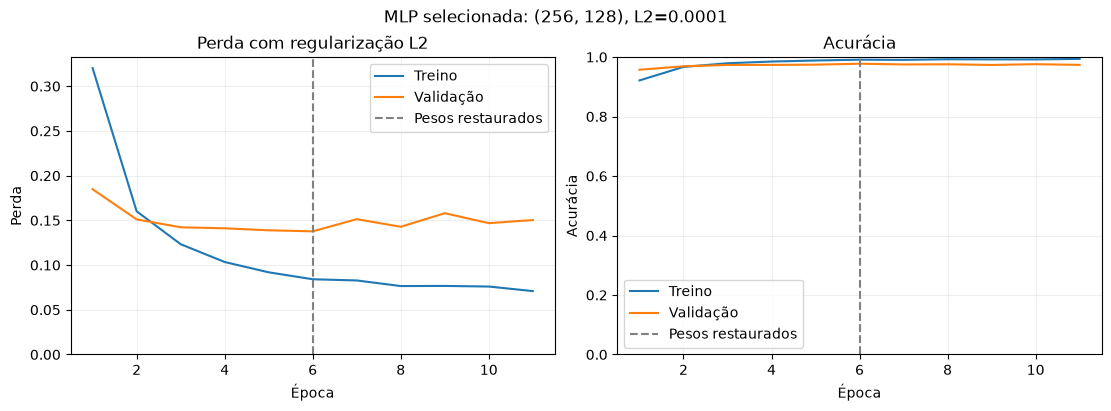

MLP selecionada salva em artifacts/melhor_mlp.keras


In [18]:
epocas = np.arange(1, len(melhor_historico_mlp["loss"]) + 1)
melhor_epoca = int(melhor_configuracao_mlp["Melhor época (val_accuracy)"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, metrica, titulo, rotulo in zip(
    axes, ("loss", "accuracy"), ("Perda com regularização L2", "Acurácia"), ("Perda", "Acurácia"),
):
    ax.plot(epocas, melhor_historico_mlp[metrica], label="Treino")
    ax.plot(epocas, melhor_historico_mlp[f"val_{metrica}"], label="Validação")
    ax.axvline(melhor_epoca, color="gray", linestyle="--", label="Pesos restaurados")
    ax.set(title=titulo, xlabel="Época", ylabel=rotulo)
    ax.grid(alpha=0.2)
    ax.legend()
axes[0].set_ylim(bottom=0)
axes[1].set_ylim(0, 1)
fig.suptitle(f"MLP selecionada: {melhor_chave_mlp[0]}, L2={melhor_chave_mlp[1]}")
fig.savefig(FIGURES_DIR / "curvas_mlp.png", dpi=150)
plt.show()

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)
melhor_mlp.save(ARTIFACTS_DIR / "melhor_mlp.keras")
tabela_mlp.to_json(ARTIFACTS_DIR / "resultados_mlp.json", orient="records", indent=2)
print("MLP selecionada salva em artifacts/melhor_mlp.keras")

**Conclusão da MLP.** A arquitetura (256, 128), com L2 de 0,0001, obteve o maior F1 ponderado na validação (0,977409) e acurácia de 0,977429: 6.842 acertos entre 7.000 imagens, com 158 erros. São 55 acertos a mais que o KNN selecionado nesta mesma amostra. Esse resultado coloca a MLP à frente dos três modelos principais na validação; a CNN é avaliada na subseção seguinte, sem consulta ao desempenho no teste nesta seleção.

A configuração selecionada possui 235.146 parâmetros, executou onze épocas e restaurou os pesos da sexta. A curva de perda de treino continuou diminuindo, enquanto a acurácia de validação não superou o máximo da sexta época nas cinco épocas seguintes. Esse padrão é compatível com início de sobreajuste e justifica a parada adotada. A perda inclui L2 e não deve ser interpretada como taxa de erro.

Esperávamos que tamanho da rede e regularização influenciassem o desempenho. O efeito observado foi consistente nas duas arquiteturas: em comparação com 0,0001, o L2 de 0,001 reduziu o F1 tanto da rede maior (0,972709 contra 0,977409) quanto da menor (0,972114 contra 0,972373). Portanto, aumentar a regularização não garantiu melhoria neste problema. As quatro configurações terminaram antes do limite de 30 épocas, entre onze e dezenove. As probabilidades verificadas foram finitas, não negativas e somaram aproximadamente 1 por imagem; essa propriedade não comprova calibração.

O modelo selecionado permanece em `melhor_mlp` e foi salvo em `artifacts/melhor_mlp.keras`, diretório local ignorado pelo Git. As curvas documentam o treinamento. As comparações refletem uma divisão e uma semente; ainda não estimam a variabilidade do ajuste.

### 4.4. CNN — rede convolucional

Acrescentamos uma arquitetura fixa e pequena, sem busca de hiperparâmetros: duas convoluções 3 × 3 com 32 e 64 filtros, cada uma seguida de max pooling 2 × 2, e uma camada densa de 64 neurônios antes da saída softmax. Usamos convoluções com `padding="valid"`, ReLU e L2 de 0,0001 na camada densa oculta.

As mesmas imagens já normalizadas são reorganizadas em 28 × 28 × 1, preservando pixels, rótulos e partições. A expectativa é que filtros locais com pesos compartilhados aproveitem a estrutura espacial dos dígitos; a comparação verificará se isso melhora o F1 nesta validação. Mantemos Adam a 0,001, lotes de 64, até 30 épocas e a mesma parada antecipada da MLP: `val_accuracy` com paciência 5 e restauração dos melhores pesos. A regra é idêntica nas duas redes de propósito, para que a comparação entre elas não dependa de orçamentos de treino diferentes. Não usamos aumento artificial de dados.

Referência: [Conv2D no TensorFlow](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D).

In [19]:
X_treino_cnn = X_treino.reshape(-1, 28, 28, 1)
X_validacao_cnn = X_validacao.reshape(-1, 28, 28, 1)
assert np.array_equal(X_treino_cnn.reshape(-1, 784), X_treino)
assert np.array_equal(X_validacao_cnn.reshape(-1, 784), X_validacao)

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(RANDOM_STATE)
modelo_cnn = tf.keras.Sequential([
    tf.keras.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="valid", name="conv_1"),
    tf.keras.layers.MaxPooling2D((2, 2), name="pool_1"),
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="valid", name="conv_2"),
    tf.keras.layers.MaxPooling2D((2, 2), name="pool_2"),
    tf.keras.layers.Flatten(name="achatamento"),
    tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.0001), name="densa"),
    tf.keras.layers.Dense(10, activation="softmax", name="saida"),
], name="cnn_mnist")
modelo_cnn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"],
)
modelo_cnn.summary()

Model: "cnn_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ achatamento (Flatten)           │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densa (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
parada_cnn = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy", patience=5, mode="max", restore_best_weights=True,
)
inicio = perf_counter()
historico_cnn = modelo_cnn.fit(
    X_treino_cnn, y_treino, validation_data=(X_validacao_cnn, y_validacao),
    epochs=30, batch_size=64, shuffle=True, callbacks=[parada_cnn], verbose=0,
)
tempo_ajuste_cnn = perf_counter() - inicio

inicio = perf_counter()
probabilidades_cnn_validacao = modelo_cnn.predict(X_validacao_cnn, batch_size=256, verbose=0)
tempo_predicao_cnn = perf_counter() - inicio
assert probabilidades_cnn_validacao.shape == (len(y_validacao), 10)
assert np.isfinite(probabilidades_cnn_validacao).all()
assert (probabilidades_cnn_validacao >= 0).all() and (probabilidades_cnn_validacao <= 1).all()
assert np.allclose(probabilidades_cnn_validacao.sum(axis=1), 1, atol=1e-5)
previsoes_cnn_validacao = probabilidades_cnn_validacao.argmax(axis=1)

resultado_cnn = {
    "Modelo": "CNN", "Parâmetros": modelo_cnn.count_params(),
    "Épocas executadas": len(historico_cnn.history["loss"]),
    "Melhor época (val_accuracy)": int(np.argmax(historico_cnn.history["val_accuracy"]) + 1),
    "F1 ponderado": f1_score(y_validacao, previsoes_cnn_validacao, average="weighted", zero_division=0),
    "Acurácia": accuracy_score(y_validacao, previsoes_cnn_validacao),
    "Tempo de ajuste (s)": tempo_ajuste_cnn,
    "Tempo de predição (s)": tempo_predicao_cnn,
}
modelo_cnn.save(ARTIFACTS_DIR / "cnn.keras")
pd.DataFrame([resultado_cnn]).to_json(ARTIFACTS_DIR / "resultado_cnn.json", orient="records", indent=2)
pd.DataFrame([resultado_cnn]).round(6)

,Modelo,Parâmetros,Épocas executadas,Melhor época (val_accuracy),F1 ponderado,Acurácia,Tempo de ajuste (s),Tempo de predição (s)
0,CNN,121930,15,10,0.988425,0.988429,50.003348,0.187124


### Curvas da CNN

A perda inclui a penalização L2. A linha vertical indica a época restaurada; as curvas completas incluem as épocas posteriores que acionaram a parada, quando aplicável.

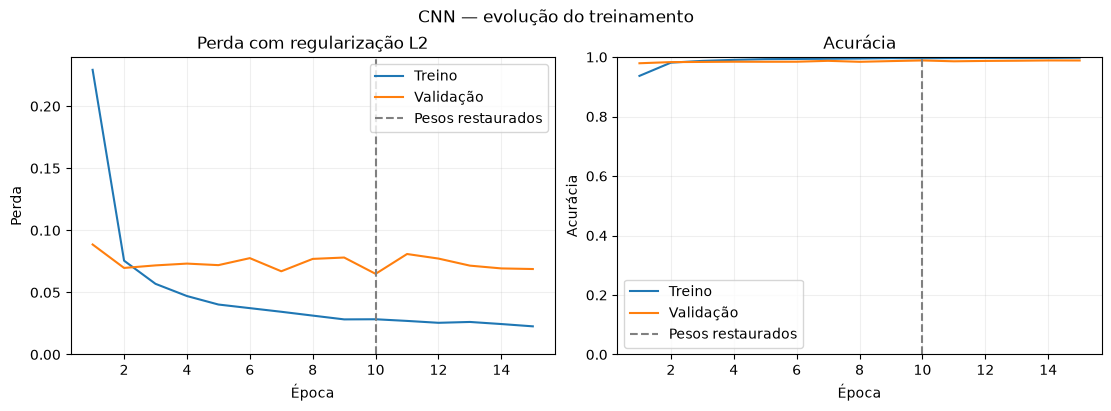

In [21]:
epocas_cnn = np.arange(1, len(historico_cnn.history["loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for ax, metrica, titulo, rotulo in zip(
    axes, ("loss", "accuracy"), ("Perda com regularização L2", "Acurácia"), ("Perda", "Acurácia"),
):
    ax.plot(epocas_cnn, historico_cnn.history[metrica], label="Treino")
    ax.plot(epocas_cnn, historico_cnn.history[f"val_{metrica}"], label="Validação")
    ax.axvline(resultado_cnn["Melhor época (val_accuracy)"], color="gray", linestyle="--", label="Pesos restaurados")
    ax.set(title=titulo, xlabel="Época", ylabel=rotulo)
    ax.grid(alpha=0.2)
    ax.legend()
axes[0].set_ylim(bottom=0)
axes[1].set_ylim(0, 1)
fig.suptitle("CNN — evolução do treinamento")
fig.savefig(FIGURES_DIR / "curvas_cnn.png", dpi=150)
plt.show()

**Conclusão da CNN.** A arquitetura fixa obteve F1 ponderado de 0,988425 e acurácia de 0,988429 na validação: 6.919 acertos entre 7.000 imagens, com 81 erros. Foram executadas quinze épocas e restaurados os pesos da décima, que apresentou a maior acurácia de validação. Nas cinco épocas posteriores, a perda de treino continuou diminuindo, mas a acurácia de validação não superou o máximo anterior; a parada seguiu o critério estabelecido.

O resultado foi superior ao da MLP selecionada nesta amostra, com 77 acertos a mais, sendo compatível com a expectativa de benefício da estrutura convolucional para imagens. A comparação não isola causalmente o efeito da convolução: arquiteturas, quantidade de parâmetros e processos de ajuste são diferentes. A CNN tem 121.930 parâmetros, contra 235.146 da MLP selecionada; menos parâmetros não implica automaticamente menor tempo de execução.

As verificações confirmaram preservação dos pixels na reorganização e probabilidades finitas, não negativas e normalizadas. O modelo foi salvo localmente em `artifacts/cnn.keras`.

### Diagramas das arquiteturas utilizadas

Os diagramas são gerados com [VisualKeras](https://github.com/paulgavrikov/visualkeras) a partir dos modelos ajustados. Os rótulos indicam tipos de camada e dimensões de saída por imagem, sem o eixo de lote. A entrada aparece no título; as tabelas incluem entrada e parâmetros. Os blocos são esquemáticos e têm dimensões visuais limitadas para legibilidade, não uma escala proporcional exata.

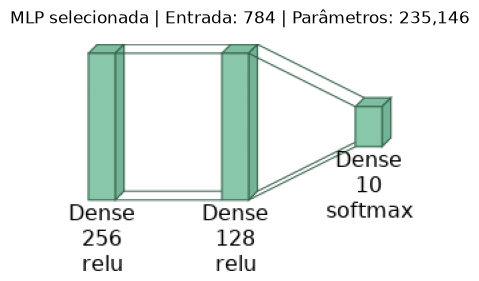

,Camada,Saída por imagem,Parâmetros
0,Entrada,784,0
1,Dense,"(256,)",200960
2,Dense,"(128,)",32896
3,Dense,"(10,)",1290


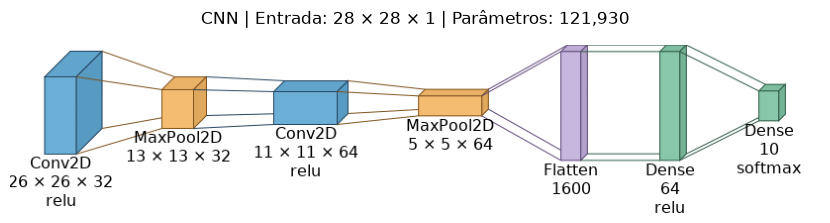

,Camada,Saída por imagem,Parâmetros
0,Entrada,28 × 28 × 1,0
1,Conv2D,"(26, 26, 32)",320
2,MaxPooling2D,"(13, 13, 32)",0
3,Conv2D,"(11, 11, 64)",18496
4,MaxPooling2D,"(5, 5, 64)",0
5,Flatten,"(1600,)",0
6,Dense,"(64,)",102464
7,Dense,"(10,)",650


In [22]:
def rotulo_camada(indice, camada):
    dimensoes = " × ".join(str(int(d)) for d in camada.output.shape[1:])
    nome = type(camada).__name__
    if nome == "MaxPooling2D":
        nome = "MaxPool2D"
    ativacao = getattr(camada, "activation", None)
    sufixo = f"\n{ativacao.__name__}" if ativacao is not None else ""
    return f"{nome}\n{dimensoes}{sufixo}", False


def diagrama_arquitetura(modelo, nome, arquivo):
    # VisualKeras 0.2 requer este metadado, ausente nas camadas do Keras 3.
    for camada in modelo.layers:
        camada.output_shape = tuple(camada.output.shape)
    fonte = ImageFont.truetype(font_manager.findfont("DejaVu Sans"), 16)
    cores = {
        tf.keras.layers.Conv2D: {"fill": "#6BAED6", "outline": "#26455F"},
        tf.keras.layers.MaxPooling2D: {"fill": "#F4BC71", "outline": "#80531E"},
        tf.keras.layers.Flatten: {"fill": "#C7B6DE", "outline": "#5F497A"},
        tf.keras.layers.Dense: {"fill": "#88C7AA", "outline": "#315C47"},
    }
    imagem = visualkeras.layered_view(
        modelo, font=fonte, text_callable=rotulo_camada,
        color_map=cores, spacing=80, padding=35,
        max_xy=110, max_z=90, scale_xy=3, scale_z=1,
        one_dim_orientation="y", legend=False, legend_text_spacing_offset=0,
    )
    fig, ax = plt.subplots(figsize=(max(8, imagem.width / 100), imagem.height / 100 + 1), layout="constrained")
    ax.imshow(imagem)
    ax.axis("off")
    entrada = " × ".join(str(int(d)) for d in modelo.input_shape[1:])
    ax.set_title(f"{nome} | Entrada: {entrada} | Parâmetros: {modelo.count_params():,}", pad=15)
    fig.savefig(FIGURES_DIR / arquivo, dpi=150)
    plt.show()
    linhas = [{"Camada": "Entrada", "Saída por imagem": entrada, "Parâmetros": 0}]
    for camada in modelo.layers:
        linhas.append({
            "Camada": type(camada).__name__,
            "Saída por imagem": str(tuple(camada.output.shape[1:])),
            "Parâmetros": camada.count_params(),
        })
    tabela = pd.DataFrame(linhas)
    assert tabela["Parâmetros"].sum() == modelo.count_params()
    display(tabela)


diagrama_arquitetura(melhor_mlp, "MLP selecionada", "arquitetura_mlp.png")
diagrama_arquitetura(modelo_cnn, "CNN", "arquitetura_cnn.png")

### Comparação dos quatro modelos na validação

As três famílias principais tiveram quatro configurações avaliadas cada uma; a CNN teve uma arquitetura fixada previamente. Esta tabela compara os modelos selecionados e não representa uma busca equivalente entre famílias. A calibração, a avaliação final no teste e o bootstrap estão nas seções 5 e 6.

In [23]:
colunas_comparacao = ["F1 ponderado", "Acurácia", "Tempo de ajuste (s)", "Tempo de predição (s)"]
comparacao_validacao = pd.DataFrame([
    {"Modelo": "KNN", **melhor_configuracao_knn[colunas_comparacao].to_dict()},
    {"Modelo": "Random Forest", **melhor_configuracao_rf[colunas_comparacao].to_dict()},
    {"Modelo": "MLP", **melhor_configuracao_mlp[colunas_comparacao].to_dict()},
    {"Modelo": "CNN", **{coluna: resultado_cnn[coluna] for coluna in colunas_comparacao}},
]).sort_values("F1 ponderado", ascending=False).reset_index(drop=True)
assert len(comparacao_validacao) == 4
comparacao_validacao.to_json(ARTIFACTS_DIR / "comparacao_validacao.json", orient="records", indent=2)
comparacao_validacao.round(6)

,Modelo,F1 ponderado,Acurácia,Tempo de ajuste (s),Tempo de predição (s)
0,CNN,0.988425,0.988429,50.003348,0.187124
1,MLP,0.977409,0.977429,7.464543,0.058045
2,KNN,0.969526,0.969571,0.005135,1.167775
3,Random Forest,0.967215,0.967286,3.735110,0.050196


**Conclusão da seleção na validação.** A ordem observada foi CNN (F1 0,988425), MLP (0,977409), KNN (0,969526) e Random Forest (0,967215). Pelo critério previamente definido, a CNN é escolhida para a calibração e para as imagens próprias. A MLP é o melhor dos três modelos principais e será a referência da comparação pareada com a CNN no bootstrap.

Essa escolha antecede a avaliação no teste e deverá ser preservada mesmo se a ordenação mudar naquele conjunto. As medidas atuais são de validação, usada também para seleção e parada das redes; portanto, não devem substituir a avaliação final. As tabelas de arquitetura conferem tipos de camada, dimensões e contagens de parâmetros com os modelos efetivamente ajustados.

## 5. Calibração da CNN selecionada

A CNN foi escolhida pelo F1 ponderado na validação. Mantemos seus pesos fixos e ajustamos somente uma temperatura positiva, `T`, usando as 7.000 imagens reservadas para calibração. A técnica aplica `softmax(logits / T)`, em que logits são as saídas anteriores à softmax. Referência: [Guo et al. (2017), On Calibration of Modern Neural Networks](https://proceedings.mlr.press/v70/guo17a.html).

Com `T = 1`, recuperamos as probabilidades originais. Valores acima de 1 suavizam a distribuição; valores abaixo de 1 a tornam mais concentrada. Como a mesma temperatura positiva é aplicada às dez classes, a ordem dos logits e a classe prevista são preservadas.

Minimizamos a entropia cruzada média (log loss) no conjunto de calibração, sem a penalização L2 do treinamento. Otimizamos `log(T)` no intervalo correspondente a `0,05 ≤ T ≤ 20`, com verificação de convergência e de solução afastada dos limites. A expectativa é melhorar o ajuste das probabilidades, sem alterar a acurácia. O teste permanece reservado: resultados nesta etapa descrevem os próprios dados usados para estimar a temperatura.

In [24]:
X_calibracao_cnn = X_calibracao.reshape(-1, 28, 28, 1)
assert np.array_equal(X_calibracao_cnn.reshape(-1, 784), X_calibracao)

extrator_cnn = tf.keras.Model(
    inputs=modelo_cnn.inputs, outputs=modelo_cnn.layers[-1].input,
)
pesos_saida, vies_saida = modelo_cnn.layers[-1].get_weights()
pesos_saida = pesos_saida.astype(np.float64)
vies_saida = vies_saida.astype(np.float64)


def obter_logits_cnn(imagens):
    caracteristicas = extrator_cnn.predict(imagens, batch_size=256, verbose=0)
    return caracteristicas.astype(np.float64) @ pesos_saida + vies_saida


logits_calibracao = obter_logits_cnn(X_calibracao_cnn)
probabilidades_originais_cal = softmax(logits_calibracao, axis=1)
probabilidades_referencia_cal = modelo_cnn.predict(X_calibracao_cnn, batch_size=256, verbose=0)
assert logits_calibracao.shape == (len(y_calibracao), 10)
assert np.isfinite(logits_calibracao).all()
assert np.allclose(probabilidades_originais_cal, probabilidades_referencia_cal, atol=1e-6)
print("Logits reconstruídos: a softmax reproduz as probabilidades da CNN.")

Logits reconstruídos: a softmax reproduz as probabilidades da CNN.


In [25]:
def log_loss_temperatura(log_temperatura, logits, rotulos):
    escores = logits / np.exp(log_temperatura)
    perdas = logsumexp(escores, axis=1) - escores[np.arange(len(rotulos)), rotulos]
    return float(perdas.mean())


limites_log_temperatura = (np.log(0.05), np.log(20.0))
ajuste_temperatura = minimize_scalar(
    log_loss_temperatura, bounds=limites_log_temperatura,
    args=(logits_calibracao, y_calibracao), method="bounded",
    options={"xatol": 1e-8},
)
assert ajuste_temperatura.success
assert np.isfinite(ajuste_temperatura.fun)
assert limites_log_temperatura[0] + 1e-3 < ajuste_temperatura.x < limites_log_temperatura[1] - 1e-3

temperatura_cnn = float(np.exp(ajuste_temperatura.x))
probabilidades_calibradas_cal = softmax(logits_calibracao / temperatura_cnn, axis=1)
assert np.isfinite(probabilidades_calibradas_cal).all()
assert (probabilidades_calibradas_cal >= 0).all()
assert np.allclose(probabilidades_calibradas_cal.sum(axis=1), 1)
assert np.array_equal(probabilidades_originais_cal.argmax(axis=1), probabilidades_calibradas_cal.argmax(axis=1))

perda_original_cal = log_loss_temperatura(0.0, logits_calibracao, y_calibracao)
perda_calibrada_cal = log_loss_temperatura(np.log(temperatura_cnn), logits_calibracao, y_calibracao)
assert perda_calibrada_cal <= perda_original_cal + 1e-10

resumo_calibracao = pd.DataFrame([
    {
        "Versão": nome, "Temperatura": temperatura,
        "Log loss — calibração": perda,
        "Acurácia — calibração": accuracy_score(y_calibracao, probabilidades.argmax(axis=1)),
        "Confiança máxima média": probabilidades.max(axis=1).mean(),
    }
    for nome, temperatura, perda, probabilidades in (
        ("Original", 1.0, perda_original_cal, probabilidades_originais_cal),
        ("Calibrada", temperatura_cnn, perda_calibrada_cal, probabilidades_calibradas_cal),
    )
])
resumo_calibracao.round(6)

,Versão,Temperatura,Log loss — calibração,Acurácia — calibração,Confiança máxima média
0,Original,1.000000,0.041688,0.989286,0.993847
1,Calibrada,1.512363,0.036179,0.989286,0.988676


### Registro do ajuste

A temperatura será reutilizada sem novo ajuste no teste e nas imagens próprias. O arquivo contém o parâmetro e os diagnósticos do conjunto de calibração. A comparação de log loss e o gráfico de confiabilidade no teste estão na seção 6; a redução da perda nos dados de ajuste não comprova, por si só, melhoria em novas imagens.

In [26]:
registro_calibracao = {
    "modelo": "CNN", "metodo": "temperature_scaling",
    "temperatura": temperatura_cnn, "imagens_calibracao": len(y_calibracao),
    "log_loss_original_calibracao": perda_original_cal,
    "log_loss_calibrada_calibracao": perda_calibrada_cal,
    "classes_previstas_preservadas": True,
}
(ARTIFACTS_DIR / "calibracao_cnn.json").write_text(
    json.dumps(registro_calibracao, ensure_ascii=False, indent=2), encoding="utf-8",
)
print(f"Temperatura ajustada: {temperatura_cnn:.6f}")
print("Ajuste registrado em artifacts/calibracao_cnn.json")

Temperatura ajustada: 1.512363
Ajuste registrado em artifacts/calibracao_cnn.json


**Conclusão da calibração.** O ajuste convergiu para temperatura 1,512363, acima de 1 e afastada dos limites da otimização. A log loss no próprio conjunto de calibração passou de 0,04168771 para 0,03617923, uma redução de aproximadamente 0,00550848. A confiança máxima média passou de 99,3847% para 98,8676%. Uma temperatura maior que 1 divide os logits e aproxima as probabilidades entre si; o valor encontrado indica que a CNN atribuía às classes escolhidas probabilidades mais altas do que a frequência de acerto justificaria, e o ajuste reduz essa diferença.

As classes previstas foram preservadas em todas as 7.000 imagens, com acurácia de 98,9286% antes e depois. Esse resultado corresponde à propriedade esperada da temperatura positiva: a transformação altera as probabilidades, mas mantém a ordenação das classes. A reconstrução dos logits também reproduziu a saída original da CNN dentro da tolerância numérica verificada.

Esses números descrevem o conjunto usado para ajustar a temperatura e não comprovam calibração adequada em novos dados. A temperatura é mantida na seção 6, que compara as probabilidades originais e calibradas no teste por log loss e gráfico de confiabilidade.

## 6. Avaliação final no teste — Fase 4

A CNN foi escolhida na validação e sua temperatura foi ajustada apenas na calibração. Avaliamos agora os quatro modelos nas mesmas 14.000 imagens de teste, sem refazer treinamento, seleção ou calibração com esses resultados. A MLP permanece como referência entre os três modelos principais.

Precisão, recall e F1 são médias ponderadas pela quantidade de exemplos de cada classe. O tempo de ajuste é o da configuração selecionada, não o custo total da busca. O tempo de inferência corresponde às 14.000 imagens nesta execução, sem repetições de benchmark; inclui os custos da chamada de predição. As redes usam lotes de 256 na inferência.

In [27]:
X_teste_cnn = X_teste.reshape(-1, 28, 28, 1)
modelos_finais = {"KNN": melhor_knn, "Random Forest": melhor_rf, "MLP": melhor_mlp, "CNN": modelo_cnn}
tempos_ajuste_finais = comparacao_validacao.set_index("Modelo")["Tempo de ajuste (s)"].to_dict()
previsoes_teste = {}
resultados_teste = []

for nome, modelo in modelos_finais.items():
    inicio = perf_counter()
    if nome in ("MLP", "CNN"):
        entradas = X_teste_cnn if nome == "CNN" else X_teste
        probabilidades = modelo.predict(entradas, batch_size=256, verbose=0)
        previsoes = probabilidades.argmax(axis=1)
        if nome == "CNN":
            probabilidades_cnn_teste = probabilidades
    else:
        previsoes = modelo.predict(X_teste)
    tempo_inferencia = perf_counter() - inicio
    assert previsoes.shape == y_teste.shape
    assert np.isin(previsoes, np.arange(10)).all()
    previsoes_teste[nome] = previsoes
    resultados_teste.append({
        "Modelo": nome, "Acurácia": accuracy_score(y_teste, previsoes),
        "Precisão ponderada": precision_score(y_teste, previsoes, average="weighted", zero_division=0),
        "Recall ponderado": recall_score(y_teste, previsoes, average="weighted", zero_division=0),
        "F1 ponderado": f1_score(y_teste, previsoes, average="weighted", zero_division=0),
        "Acertos": int((previsoes == y_teste).sum()),
        "Tempo de ajuste (s)": tempos_ajuste_finais[nome],
        "Tempo de inferência (s)": tempo_inferencia,
    })

tabela_teste = pd.DataFrame(resultados_teste).sort_values("F1 ponderado", ascending=False).reset_index(drop=True)
TABLES_DIR = Path("reports/tables")
TABLES_DIR.mkdir(parents=True, exist_ok=True)
tabela_teste.to_csv(TABLES_DIR / "metricas_teste.csv", index=False)
tabela_teste.round(6)

,Modelo,Acurácia,Precisão ponderada,Recall ponderado,F1 ponderado,Acertos,Tempo de ajuste (s),Tempo de inferência (s)
0,CNN,0.989929,0.989949,0.989929,0.989933,13859,50.003348,0.294652
1,MLP,0.976571,0.976573,0.976571,0.976551,13672,7.464543,0.089735
2,KNN,0.970286,0.970562,0.970286,0.970257,13584,0.005135,2.215531
3,Random Forest,0.965714,0.965740,0.965714,0.965695,13520,3.735110,0.087431


**Conclusão das métricas no teste.** A ordem por F1 foi preservada: CNN (0,989933), MLP (0,976551), KNN (0,970257) e Random Forest (0,965695). A CNN acertou 13.859 das 14.000 imagens, com 141 erros, e superou a MLP em 187 acertos. A acurácia da CNN foi de 98,9929%. O recall ponderado coincide com a acurácia neste problema multiclasse de rótulo único, pois a ponderação pelo suporte resulta na proporção global de acertos.

O resultado sustenta a escolha prévia da CNN para este experimento. A tabela registra o compromisso entre desempenho e tempo: a CNN teve maior tempo de ajuste entre as configurações selecionadas, enquanto a MLP teve menor tempo de inferência nesta execução. Esses tempos dependem do equipamento, paralelismo e custos das chamadas; não representam um benchmark controlado.

### Matrizes de confusão e resultados por dígito

Linhas representam os rótulos verdadeiros e colunas as previsões. A diagonal contém os acertos. As quatro matrizes usam a mesma escala de cores e mostram contagens absolutas. A tabela de F1 por classe complementa as médias ponderadas.

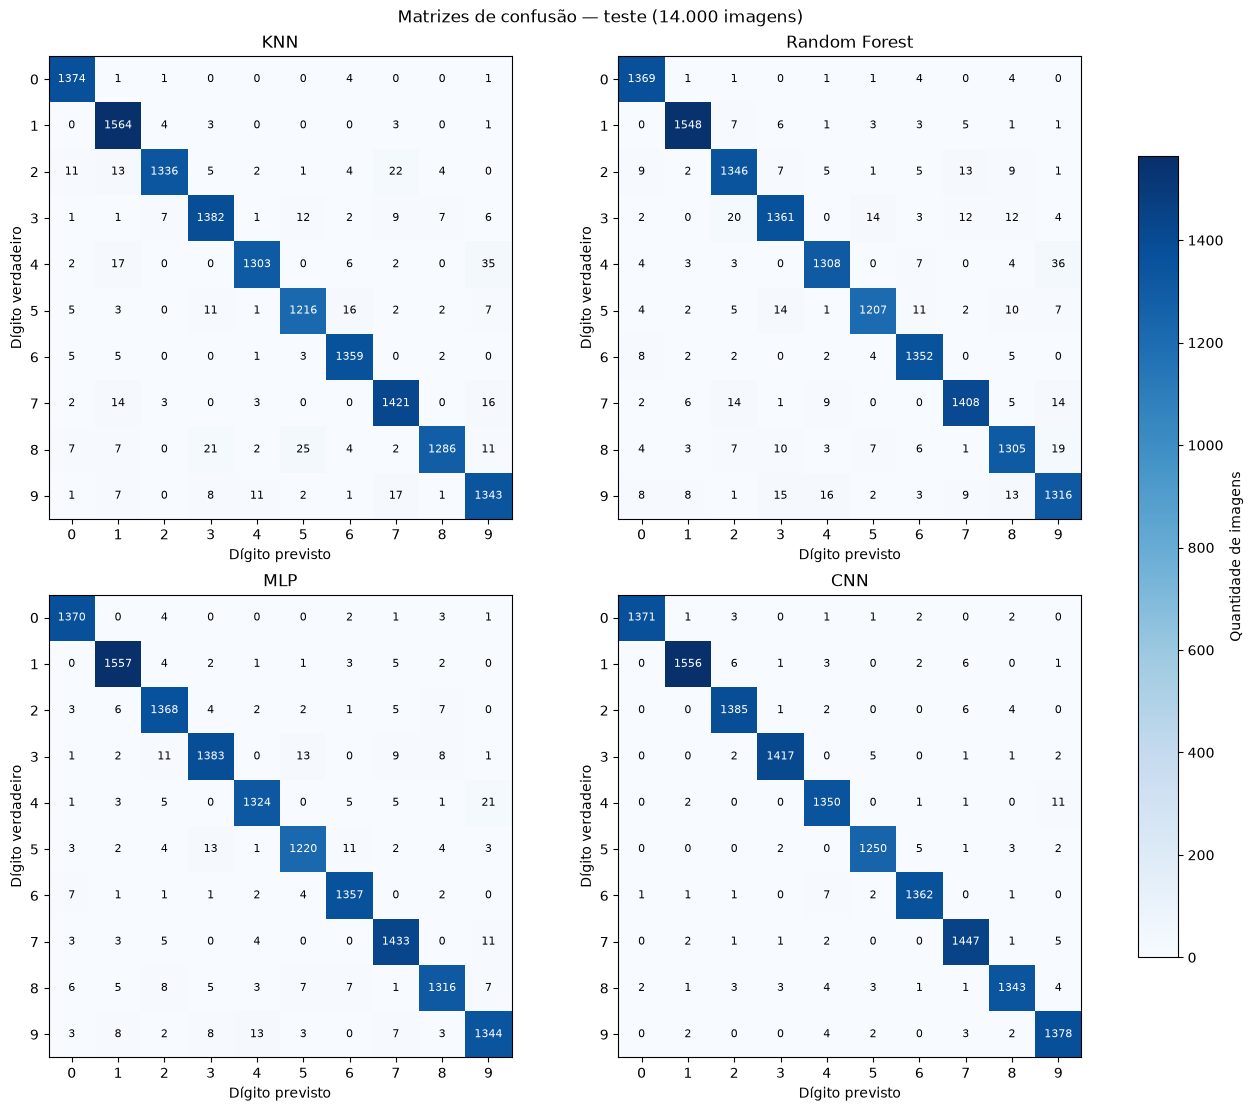

,KNN,Random Forest,MLP,CNN,Imagens de teste
Dígito,,,,,
0,0.9853,0.9810,0.9863,0.9953,1381
1,0.9754,0.9829,0.9848,0.9911,1575
2,0.9720,0.9601,0.9737,0.9896,1398
3,0.9671,0.9578,0.9726,0.9933,1428
4,0.9691,0.9650,0.9753,0.9861,1365
5,0.9643,0.9648,0.9710,0.9897,1263
6,0.9809,0.9765,0.9830,0.9913,1375
7,0.9677,0.9680,0.9792,0.9894,1459
8,0.9644,0.9550,0.9709,0.9868,1365


In [28]:
matrizes_teste = {nome: confusion_matrix(y_teste, prev, labels=np.arange(10)) for nome, prev in previsoes_teste.items()}
limite_cor = max(matriz.max() for matriz in matrizes_teste.values())
fig, axes = plt.subplots(2, 2, figsize=(13, 11), layout="constrained")
for ax, (nome, matriz) in zip(axes.flat, matrizes_teste.items()):
    assert matriz.sum() == len(y_teste)
    mapa = ax.imshow(matriz, cmap="Blues", vmin=0, vmax=limite_cor)
    for verdadeiro in range(10):
        for previsto in range(10):
            valor = matriz[verdadeiro, previsto]
            ax.text(previsto, verdadeiro, str(valor), ha="center", va="center", fontsize=8,
                    color="white" if valor > limite_cor * 0.5 else "black")
    ax.set(title=nome, xlabel="Dígito previsto", ylabel="Dígito verdadeiro", xticks=range(10), yticks=range(10))
fig.colorbar(mapa, ax=axes.ravel().tolist(), label="Quantidade de imagens", shrink=0.8)
fig.suptitle("Matrizes de confusão — teste (14.000 imagens)")
fig.savefig(FIGURES_DIR / "matrizes_confusao_teste.png", dpi=150)
plt.show()

relatorios_classes = {nome: classification_report(y_teste, prev, labels=np.arange(10), output_dict=True, zero_division=0) for nome, prev in previsoes_teste.items()}
f1_por_digito = pd.DataFrame({nome: [relatorio[str(d)]["f1-score"] for d in range(10)] for nome, relatorio in relatorios_classes.items()}, index=pd.Index(range(10), name="Dígito"))
f1_por_digito["Imagens de teste"] = np.bincount(y_teste, minlength=10)
f1_por_digito.to_csv(TABLES_DIR / "f1_por_digito.csv")
f1_por_digito.round(4)

In [29]:
confusoes_frequentes = []
for nome, matriz in matrizes_teste.items():
    erros = matriz.copy()
    np.fill_diagonal(erros, 0)
    for posicao in np.argsort(-erros.ravel(), kind="stable")[:3]:
        verdadeiro, previsto = np.unravel_index(posicao, erros.shape)
        confusoes_frequentes.append({"Modelo": nome, "Verdadeiro": verdadeiro, "Previsto": previsto, "Quantidade": int(erros[verdadeiro, previsto])})
confusoes_frequentes = pd.DataFrame(confusoes_frequentes)
confusoes_frequentes.to_csv(TABLES_DIR / "confusoes_frequentes.csv", index=False)
confusoes_frequentes

,Modelo,Verdadeiro,Previsto,Quantidade
0,KNN,4,9,35
1,KNN,8,5,25
2,KNN,2,7,22
3,Random Forest,4,9,36
4,Random Forest,3,2,20
5,Random Forest,8,9,19
6,MLP,4,9,21
7,MLP,3,5,13
8,MLP,5,3,13
9,CNN,4,9,11


**Conclusão dos erros por dígito.** O dígito 9 teve o menor F1 em todos os modelos, incluindo a CNN (0,9745). Na CNN, a confusão mais frequente foi 9 → 4, com 16 imagens, seguida de 5 → 6 (12) e 5 → 3 (11). KNN, Random Forest e MLP tiveram 4 → 9 como confusão mais frequente, com 35, 36 e 21 imagens, respectivamente. As matrizes e a tabela por classe mostram que a elevada média global não elimina erros sistemáticos entre determinados dígitos.

### Probabilidades originais e calibradas no teste

Aplicamos a temperatura já fixada, sem novo ajuste. A log loss mede a qualidade probabilística global. O diagrama de confiabilidade agrupa a maior probabilidade de cada imagem em dez intervalos de largura 0,1 e compara confiança média com frequência de acerto. O ECE é a média ponderada dos desvios absolutos desses grupos; depende dos intervalos escolhidos e não substitui a log loss. O histograma mostra quantas imagens sustentam cada intervalo.

In [30]:
logits_teste = obter_logits_cnn(X_teste_cnn)
probabilidades_originais_teste = softmax(logits_teste, axis=1)
probabilidades_calibradas_teste = softmax(logits_teste / temperatura_cnn, axis=1)
assert np.allclose(probabilidades_originais_teste, probabilidades_cnn_teste, atol=1e-6)
assert np.isfinite(probabilidades_calibradas_teste).all()
assert np.allclose(probabilidades_calibradas_teste.sum(axis=1), 1)
assert np.array_equal(probabilidades_calibradas_teste.argmax(axis=1), previsoes_teste["CNN"])


def confiabilidade(probabilidades, rotulos):
    confianca = probabilidades.max(axis=1)
    acerto = probabilidades.argmax(axis=1) == rotulos
    grupos = np.minimum((confianca * 10).astype(int), 9)
    linhas = []
    for grupo in range(10):
        mascara = grupos == grupo
        quantidade = int(mascara.sum())
        linhas.append({"Intervalo": grupo, "Quantidade": quantidade,
                       "Confiança média": confianca[mascara].mean() if quantidade else np.nan,
                       "Frequência de acerto": acerto[mascara].mean() if quantidade else np.nan})
    tabela = pd.DataFrame(linhas)
    assert tabela["Quantidade"].sum() == len(rotulos)
    validos = tabela["Quantidade"] > 0
    ece = float((tabela.loc[validos, "Quantidade"] / len(rotulos) *
                 (tabela.loc[validos, "Confiança média"] - tabela.loc[validos, "Frequência de acerto"]).abs()).sum())
    return tabela, ece


curvas_confiabilidade = {}
resultados_probabilidades = []
for versao, probabilidades in (("Original", probabilidades_originais_teste), ("Calibrada", probabilidades_calibradas_teste)):
    curva, ece = confiabilidade(probabilidades, y_teste)
    curvas_confiabilidade[versao] = curva
    resultados_probabilidades.append({"CNN": versao, "Temperatura": 1.0 if versao == "Original" else temperatura_cnn,
        "Log loss": log_loss(y_teste, probabilidades, labels=np.arange(10)), "ECE (10 intervalos)": ece,
        "Acurácia": accuracy_score(y_teste, probabilidades.argmax(axis=1)),
        "F1 ponderado": f1_score(y_teste, probabilidades.argmax(axis=1), average="weighted", zero_division=0)})
tabela_probabilidades_teste = pd.DataFrame(resultados_probabilidades)
tabela_probabilidades_teste.to_csv(TABLES_DIR / "calibracao_teste.csv", index=False)
tabela_probabilidades_teste.round(8)

,CNN,Temperatura,Log loss,ECE (10 intervalos),Acurácia,F1 ponderado
0,Original,1.000000,0.037568,0.004895,0.989929,0.989933
1,Calibrada,1.512363,0.032713,0.000993,0.989929,0.989933


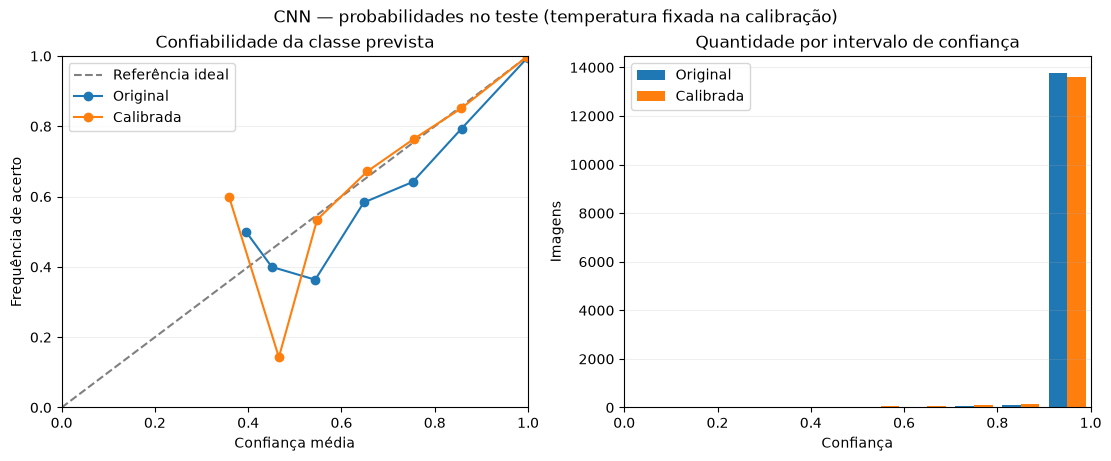

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), layout="constrained")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Referência ideal")
for indice, (versao, curva) in enumerate(curvas_confiabilidade.items()):
    validos = curva["Quantidade"] > 0
    axes[0].plot(curva.loc[validos, "Confiança média"], curva.loc[validos, "Frequência de acerto"], marker="o", label=versao)
    centros = (curva["Intervalo"].to_numpy() + 0.5) / 10
    axes[1].bar(centros + (indice - 0.5) * 0.04, curva["Quantidade"], width=0.04, label=versao)
axes[0].set(title="Confiabilidade da classe prevista", xlabel="Confiança média", ylabel="Frequência de acerto", xlim=(0, 1), ylim=(0, 1))
axes[1].set(title="Quantidade por intervalo de confiança", xlabel="Confiança", ylabel="Imagens", xlim=(0, 1))
for ax in axes:
    ax.legend()
    ax.grid(axis="y", alpha=0.2)
fig.suptitle("CNN — probabilidades no teste (temperatura fixada na calibração)")
fig.savefig(FIGURES_DIR / "confiabilidade_teste.png", dpi=150)
plt.show()

**Conclusão da calibração no teste.** A log loss passou de 0,03756771 para 0,03271348 e o ECE, com dez intervalos, de 0,00489486 para 0,00099256. Ambas as medidas melhoraram após a aplicação da temperatura 1,512363: a log loss caiu cerca de 12,9% e o ECE ficou aproximadamente cinco vezes menor. Assim, a melhora obtida no conjunto de calibração se reproduziu em dados que não participaram do ajuste da temperatura, o que sustenta o benefício desta calibração segundo as medidas observadas.

Acurácia e F1 permaneceram idênticos, conforme esperado pela preservação das classes previstas. As curvas são próximas e a maior parte das imagens se concentra no intervalo de confiança entre 0,9 e 1; os grupos menos confiantes têm poucas observações, exigindo cautela na leitura das oscilações. Preservamos o ajuste definido antes do teste e relatamos seu efeito, sem reotimizar a temperatura com esse conjunto.

### Bootstrap pareado: CNN versus MLP

Estimamos um intervalo percentil de 95% para a diferença `F1 ponderado da CNN − F1 ponderado da MLP`, com 1.000 reamostragens de tamanho 14.000 e semente 42. Cada reamostragem usa os mesmos índices para os dois modelos e permite repetições; nenhum modelo é retreinado. A comparação usa a CNN original, cujas classes previstas são preservadas pela calibração.

O intervalo descreve a variação amostral do teste, condicionada a estes modelos ajustados e à hipótese de exemplos independentes. Não incorpora a variabilidade de treinamento, de escolha da divisão ou de seleção dos modelos. Calculamos o F1 a partir das matrizes de confusão para tornar a reamostragem eficiente e verificamos a equivalência com o scikit-learn.

In [32]:
def f1_ponderado_matriz(matriz):
    suporte = matriz.sum(axis=1)
    denominador = suporte + matriz.sum(axis=0)
    f1_classes = np.divide(2 * np.diag(matriz), denominador,
                           out=np.zeros(10, dtype=float), where=denominador > 0)
    return float(np.dot(f1_classes, suporte) / suporte.sum())


for nome in ("CNN", "MLP"):
    assert np.isclose(f1_ponderado_matriz(matrizes_teste[nome]), f1_score(y_teste, previsoes_teste[nome], average="weighted"))

rng_bootstrap = np.random.default_rng(RANDOM_STATE)
diferencas_bootstrap = np.empty(1_000)
codigos_cnn = y_teste.astype(int) * 10 + previsoes_teste["CNN"]
codigos_mlp = y_teste.astype(int) * 10 + previsoes_teste["MLP"]
for repeticao in range(len(diferencas_bootstrap)):
    amostra = rng_bootstrap.integers(0, len(y_teste), size=len(y_teste))
    matriz_cnn = np.bincount(codigos_cnn[amostra], minlength=100).reshape(10, 10)
    matriz_mlp = np.bincount(codigos_mlp[amostra], minlength=100).reshape(10, 10)
    diferencas_bootstrap[repeticao] = f1_ponderado_matriz(matriz_cnn) - f1_ponderado_matriz(matriz_mlp)

diferenca_observada = f1_ponderado_matriz(matrizes_teste["CNN"]) - f1_ponderado_matriz(matrizes_teste["MLP"])
limite_inferior, limite_superior = np.quantile(diferencas_bootstrap, [0.025, 0.975])
resumo_bootstrap = pd.DataFrame([{"Comparação": "CNN − MLP", "Diferença de F1": diferenca_observada,
    "Limite inferior (95%)": limite_inferior, "Limite superior (95%)": limite_superior,
    "Reamostragens": len(diferencas_bootstrap)}])
resumo_bootstrap.to_csv(TABLES_DIR / "bootstrap_cnn_mlp.csv", index=False)
resumo_bootstrap.round(6)

,Comparação,Diferença de F1,Limite inferior (95%),Limite superior (95%),Reamostragens
0,CNN − MLP,0.013382,0.011304,0.015602,1000


**Conclusão do bootstrap e da avaliação.** A diferença observada de F1 ponderado entre CNN e MLP foi de 0,013382, com intervalo percentil de 95% de [0,011304; 0,015602], estimado por 1.000 reamostragens pareadas. Em uma escala de F1 de 0 a 100, isso corresponde a 1,3382 ponto, com intervalo de 1,1304 a 1,5602 ponto.

Como o intervalo ficou inteiramente acima de zero, a análise sustenta uma vantagem da CNN sobre a MLP diante da variação amostral do teste, condicionada aos modelos ajustados. Não se trata de uma garantia para qualquer conjunto de imagens nem de uma estimativa da variabilidade entre novos treinamentos.

A CNN permanece selecionada para as imagens próprias. O desafio de classes ocultadas utiliza uma nova Random Forest, conforme o planejamento. O desempenho no MNIST e a calibração avaliada aqui não garantem reconhecimento de classes ausentes do treino ou de imagens próprias com aparência diferente; esses comportamentos serão examinados nos experimentos seguintes.

## 7. Classes ausentes do treinamento — Fase 5, desafios A e B

Removemos os dígitos 4 e 7 apenas do conjunto de treino e ajustamos uma **nova** Random Forest com 200 árvores, profundidade máxima 20, `max_features="sqrt"`, amostragem com reposição e semente 42. Essa configuração foi fixada no planejamento do experimento; não reutilizamos os pesos ou árvores do modelo treinado nas dez classes.

A avaliação usa exclusivamente os dígitos 4 e 7 da partição de teste. Como o classificador só pode emitir as oito classes aprendidas, esperamos acurácia zero por construção. A pergunta relevante é quais classes receberão esses exemplos e com que probabilidades. Uma probabilidade elevada entre classes conhecidas não comprova que a entrada pertença a alguma delas.

Esta seção discute também o conceito de **falsa certeza** (*overconfidence*): a situação em que um modelo atribui probabilidade alta a uma previsão incorreta. Aqui ela aparece na forma mais extrema possível, porque toda previsão sobre um 4 ou um 7 está necessariamente errada; o que resta medir é com quanta confiança o modelo erra.

As colunas de `predict_proba` são interpretadas por `classes_`. O limiar de 90% será usado apenas como descrição de previsões com confiança elevada, não como detector de classes desconhecidas.

In [33]:
classes_ocultadas = np.array([4, 7])
mascara_treino_conhecidas = ~np.isin(y_treino, classes_ocultadas)
mascara_teste_ocultadas = np.isin(y_teste, classes_ocultadas)
X_treino_conhecidas = X_treino[mascara_treino_conhecidas]
y_treino_conhecidas = y_treino[mascara_treino_conhecidas]
X_teste_ocultadas = X_teste[mascara_teste_ocultadas]
y_teste_ocultadas = y_teste[mascara_teste_ocultadas]
classes_conhecidas = np.setdiff1d(np.arange(10), classes_ocultadas)

assert np.array_equal(np.unique(y_treino_conhecidas), classes_conhecidas)
assert np.array_equal(np.unique(y_teste_ocultadas), classes_ocultadas)
assert len(y_teste_ocultadas) == 2_824
assert not np.isin(y_treino_conhecidas, classes_ocultadas).any()

pd.DataFrame({
    "Conjunto": ["Treino após exclusão", "Teste: somente 4 e 7"],
    "Imagens": [len(y_treino_conhecidas), len(y_teste_ocultadas)],
    "Classes presentes": [str(np.unique(y_treino_conhecidas).tolist()), str(np.unique(y_teste_ocultadas).tolist())],
})

,Conjunto,Imagens,Classes presentes
0,Treino após exclusão,33531,"[0, 1, 2, 3, 5, 6, 8, 9]"
1,Teste: somente 4 e 7,2824,"[4, 7]"


In [34]:
rf_classes_ocultadas = RandomForestClassifier(
    n_estimators=200, max_depth=20, max_features="sqrt", bootstrap=True,
    random_state=RANDOM_STATE, n_jobs=-1,
)
inicio = perf_counter()
rf_classes_ocultadas.fit(X_treino_conhecidas, y_treino_conhecidas)
tempo_ajuste_ocultadas = perf_counter() - inicio
assert np.array_equal(rf_classes_ocultadas.classes_, classes_conhecidas)

probabilidades_ocultadas = rf_classes_ocultadas.predict_proba(X_teste_ocultadas)
previsoes_ocultadas = rf_classes_ocultadas.classes_[probabilidades_ocultadas.argmax(axis=1)]
confiancas_ocultadas = probabilidades_ocultadas.max(axis=1)
assert probabilidades_ocultadas.shape == (len(y_teste_ocultadas), 8)
assert np.isfinite(probabilidades_ocultadas).all()
assert (probabilidades_ocultadas >= 0).all()
assert np.allclose(probabilidades_ocultadas.sum(axis=1), 1)
assert np.array_equal(previsoes_ocultadas, rf_classes_ocultadas.predict(X_teste_ocultadas))
assert not np.isin(previsoes_ocultadas, classes_ocultadas).any()
acuracia_ocultadas = accuracy_score(y_teste_ocultadas, previsoes_ocultadas)
assert acuracia_ocultadas == 0

print("Ordem das colunas de probabilidades:", rf_classes_ocultadas.classes_)
print(f"Acurácia nas classes ausentes do treino: {acuracia_ocultadas:.1%}")
print(f"Tempo de ajuste: {tempo_ajuste_ocultadas:.3f} s")

Ordem das colunas de probabilidades: [0 1 2 3 5 6 8 9]
Acurácia nas classes ausentes do treino: 0.0%
Tempo de ajuste: 2.926 s


**Conclusão da preparação e do ajuste.** A exclusão de 4 e 7 deixou 33.531 imagens de treino, com as oito classes esperadas. O teste deste experimento contém 1.365 imagens do dígito 4 e 1.459 do dígito 7, totalizando 2.824. O novo modelo emitiu somente as classes [0, 1, 2, 3, 5, 6, 8, 9] e obteve acurácia zero, conforme previsto por sua impossibilidade de emitir os rótulos verdadeiros. Esse resultado não indica falha de execução; demonstra a limitação de um classificador com conjunto fechado de saídas.

### Destinos das previsões

A matriz mantém os rótulos de 0 a 9 nos dois eixos. Somente as linhas 4 e 7 contêm exemplos; as colunas 4 e 7 devem permanecer vazias porque essas classes não foram aprendidas. A tabela apresenta a distribuição percentual das previsões para cada classe verdadeira.

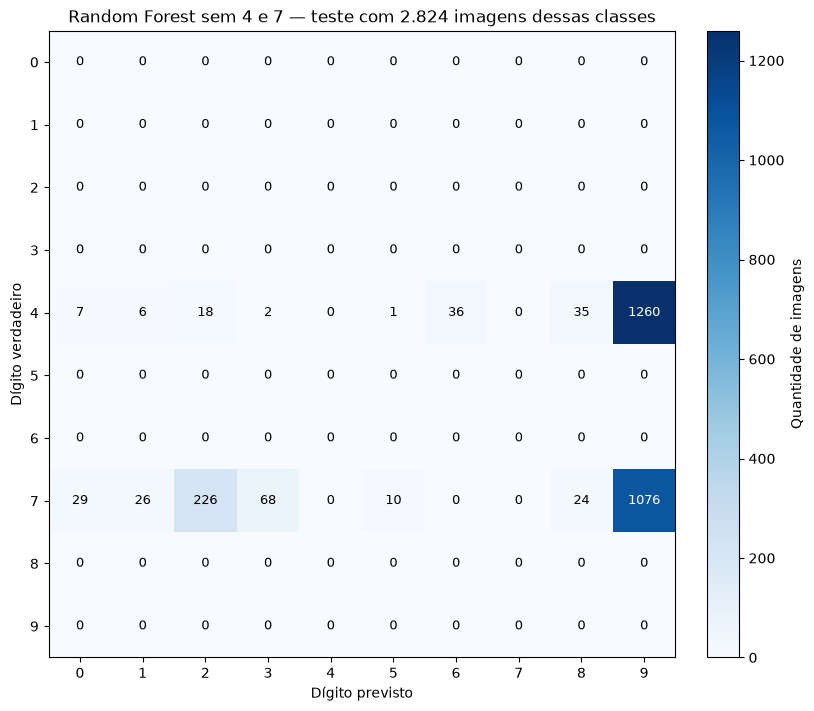

Dígito previsto,0,1,2,3,5,6,8,9
Dígito verdadeiro,,,,,,,,
4,0.51,0.44,1.32,0.15,0.07,2.64,2.56,92.31
7,1.99,1.78,15.49,4.66,0.69,0.00,1.64,73.75


In [35]:
matriz_ocultadas = confusion_matrix(y_teste_ocultadas, previsoes_ocultadas, labels=np.arange(10))
assert matriz_ocultadas.sum() == len(y_teste_ocultadas)
assert matriz_ocultadas[:, classes_ocultadas].sum() == 0
fig, ax = plt.subplots(figsize=(8, 7), layout="constrained")
mapa = ax.imshow(matriz_ocultadas, cmap="Blues", vmin=0)
for verdadeiro in range(10):
    for previsto in range(10):
        valor = matriz_ocultadas[verdadeiro, previsto]
        ax.text(previsto, verdadeiro, str(valor), ha="center", va="center", fontsize=9,
                color="white" if valor > matriz_ocultadas.max() * 0.5 else "black")
ax.set(title="Random Forest sem 4 e 7 — teste com 2.824 imagens dessas classes",
       xlabel="Dígito previsto", ylabel="Dígito verdadeiro", xticks=range(10), yticks=range(10))
fig.colorbar(mapa, ax=ax, label="Quantidade de imagens")
fig.savefig(FIGURES_DIR / "confusao_classes_ocultadas.png", dpi=150)
plt.show()

destinos_ocultadas = pd.DataFrame(matriz_ocultadas[classes_ocultadas][:, classes_conhecidas],
    index=pd.Index(classes_ocultadas, name="Dígito verdadeiro"), columns=classes_conhecidas)
destinos_ocultadas.columns.name = "Dígito previsto"
destinos_ocultadas.to_csv(TABLES_DIR / "destinos_classes_ocultadas.csv")
percentuais_destinos = destinos_ocultadas.div(destinos_ocultadas.sum(axis=1), axis=0) * 100
percentuais_destinos.round(2)

### Falsa certeza (*overconfidence*): confiança em previsões incorretas

Chamamos de falsa certeza um erro acompanhado de probabilidade alta. Como todas as previsões deste subconjunto são erros, a medida de interesse é a fração delas que o modelo emite com confiança elevada.

A confiança é a maior probabilidade entre as oito classes disponíveis. Todas as previsões deste subconjunto estão erradas em relação ao rótulo verdadeiro. O resumo permite verificar se a ausência da classe produz, de fato, baixa confiança. Os exemplos da tabela seguinte são os três de maior confiança de cada classe ausente; são casos selecionados para inspecionar o extremo da distribuição.

In [36]:
limiar_confianca_elevada = 0.90
analise_ocultadas = pd.DataFrame({
    "Índice no MNIST": indices_teste[mascara_teste_ocultadas],
    "Verdadeiro": y_teste_ocultadas, "Previsto": previsoes_ocultadas,
    "Confiança": confiancas_ocultadas,
})
resumo_ocultadas = analise_ocultadas.groupby("Verdadeiro").agg(
    Imagens=("Confiança", "size"),
    Confianca_media=("Confiança", "mean"),
    Confianca_mediana=("Confiança", "median"),
    Confianca_maxima=("Confiança", "max"),
    Erros_com_confianca_90=("Confiança", lambda valores: int((valores >= limiar_confianca_elevada).sum())),
)
resumo_ocultadas["Percentual de erros com confiança ≥90%"] = resumo_ocultadas["Erros_com_confianca_90"] / resumo_ocultadas["Imagens"] * 100
resumo_ocultadas.to_csv(TABLES_DIR / "confianca_classes_ocultadas.csv")
resumo_ocultadas.round(4)

,Imagens,Confianca_media,Confianca_mediana,Confianca_maxima,Erros_com_confianca_90,Percentual de erros com confiança ≥90%
Verdadeiro,,,,,,
4,1365,0.5814,0.5888,0.9855,45,3.2967
7,1459,0.5492,0.5149,0.9845,61,4.1809


In [37]:
indices_extremos = analise_ocultadas.sort_values("Confiança", ascending=False).groupby("Verdadeiro", sort=True).head(3).index
probabilidades_rotuladas = pd.DataFrame(probabilidades_ocultadas, columns=[f"P({digito})" for digito in rf_classes_ocultadas.classes_])
exemplos_ocultadas = pd.concat([analise_ocultadas, probabilidades_rotuladas], axis=1).loc[indices_extremos].sort_values(["Verdadeiro", "Confiança"], ascending=[True, False])
exemplos_ocultadas.to_csv(TABLES_DIR / "exemplos_classes_ocultadas.csv", index=False)
exemplos_ocultadas.round(4)

,Índice no MNIST,Verdadeiro,Previsto,Confiança,P(0),P(1),P(2),P(3),P(5),P(6),P(8),P(9)
184,51944,4,9,0.9855,0.0000,0.0012,0.0002,0.0015,0.0107,0.000,0.0010,0.9855
498,45834,4,9,0.9648,0.0000,0.0019,0.0052,0.0014,0.0155,0.010,0.0011,0.9648
1690,50014,4,9,0.9522,0.0000,0.0003,0.0051,0.0059,0.0154,0.005,0.0160,0.9522
60,11125,7,9,0.9845,0.0001,0.0005,0.0002,0.0068,0.0010,0.000,0.0069,0.9845
1834,65532,7,9,0.9758,0.0000,0.0065,0.0052,0.0061,0.0005,0.000,0.0060,0.9758
2207,54761,7,9,0.9754,0.0000,0.0066,0.0052,0.0113,0.0005,0.000,0.0010,0.9754


**Conclusão das classes ocultadas.** A Random Forest encaminhou 1.260 dos 1.365 dígitos 4 para a classe 9 (92,31%). Entre os dígitos 7, 1.076 de 1.459 foram previstos como 9 (73,75%) e 226 como 2 (15,49%). Portanto, a falta das classes não levou o modelo a emitir uma resposta de desconhecimento: ele atribuiu os exemplos às alternativas disponíveis.

A confiança máxima média foi de 58,14% para os dígitos 4 e 54,92% para os 7, mas houve erros com confiança elevada. Foram 45 imagens de 4 e 61 de 7 com confiança de pelo menos 90%: 106 casos, ou 3,75% das 2.824 imagens. As maiores confianças foram de 98,55% e 98,45%, respectivamente, ambas em previsões de classe 9. Os exemplos extremos estão identificados por seu índice original no MNIST e apresentam as oito probabilidades com rótulos corretos.

**Falsa certeza (*overconfidence*).** O termo nomeia a distância entre a confiança que um modelo declara e sua taxa real de acerto. Aqui essa distância é máxima por construção: a taxa de acerto é zero, logo qualquer probabilidade declarada já é excessiva. Os números acima, porém, descrevem um comportamento mais específico do que «o modelo tem certeza e erra». Com média de confiança abaixo de 60% e mediana semelhante, na maior parte das 2.824 imagens o classificador não expressou certeza alta. O problema está na cauda: as 106 previsões com pelo menos 90%, chegando a 98,55%. Uma aplicação que tratasse a probabilidade máxima como garantia aceitaria exatamente esses casos sem qualquer sinal de que a entrada não pertencia a nenhuma classe aprendida. Alta confiança entre classes conhecidas, portanto, não assegura reconhecimento de uma classe ausente do treinamento. Este experimento não implementa um mecanismo de rejeição nem avalia sua eficácia. As probabilidades são as deste novo Random Forest, sem calibração; a temperatura ajustada anteriormente pertence à CNN e não se aplica a ele.

### Reconhecer uma classe e saber quando recusar

Em uma aplicação, pode ser preferível responder «não reconheço» a apresentar uma resposta incorreta com alta confiança. O classificador utilizado, porém, foi treinado para escolher entre as classes disponíveis; ele não possui uma saída de desconhecimento. Acrescentar árvores ou exemplos das mesmas oito classes não cria os rótulos 4 e 7.

A concentração das previsões na classe 9 foi aprendida neste experimento, não imposta pelo código. As árvores tomam decisões sobre os pixels e encaminham cada entrada para classes conhecidas. Sem uma análise das imagens e dos caminhos individuais das árvores, a matriz de confusão não identifica quais traços explicam cada erro.

Para reconhecer 4 e 7, é necessário incluí-los no treinamento, como nos modelos completos. Para recusar entradas desconhecidas, seria necessário projetar e avaliar um mecanismo adicional. Um limiar de confiança pode ajudar, mas os 106 erros com confiança de pelo menos 90% mostram que ele não basta para todos os casos. Uma classe «outros» também dependeria dos exemplos usados para representá-la. Incerteza entre classes conhecidas e presença de uma classe desconhecida são situações distintas; uma solução de rejeição precisaria ser avaliada em ambas, inclusive medindo recusas indevidas de exemplos conhecidos.

## 8. Imagens próprias — Fase 5, desafio C

Foram fornecidas três fotografias, cada uma contendo os dígitos de 0 a 9. A foto `IMG_7057.heic` fornece dez exemplos de **desenvolvimento do processamento**; `IMG_7058.heic` e `IMG_7059.heic` fornecem vinte exemplos reservados para avaliação posterior. Essas imagens não serão usadas para treinar os classificadores.

A cópia de trabalho da primeira foto foi orientada por rotação de 90° no sentido anti-horário e reduzida proporcionalmente para 3.200 × 1.800 pixels em PNG RGB. O original permanece preservado. As coordenadas dos dez recortes foram anotadas manualmente, com rótulo e finalidade registrados em `data/imagens_proprias/manifesto.csv`; a preparação da foto está em `preparacao_fotos.json`.

O processamento converte o recorte para cinza, estima a iluminação de fundo, extrai o traço escuro por contraste relativo e remove componentes muito pequenos. Uma expansão proporcional de 2% compensa a espessura fina da caneta antes da redução. O dígito cabe em uma área de até 20 × 20, preservando proporção, e é centralizado pelo centro de massa em uma tela preta 28 × 28. Os parâmetros foram definidos pela inspeção dos dez exemplos de desenvolvimento; as vinte imagens reservadas são avaliadas adiante, com os parâmetros já fixados.

In [38]:
IMAGENS_PROPRIAS_DIR = Path("data/imagens_proprias")
manifesto_proprias = pd.read_csv(IMAGENS_PROPRIAS_DIR / "manifesto.csv")
manifesto_dev = manifesto_proprias.loc[manifesto_proprias["finalidade"] == "desenvolvimento"].sort_values("rotulo")
assert len(manifesto_dev) == 10
assert manifesto_dev["rotulo"].tolist() == list(range(10))
assert manifesto_dev["fonte_original"].unique().tolist() == ["IMG_7057.heic"]

PARAMETROS_PREPROCESSAMENTO = {"limiar_contraste": 0.15, "tamanho_interno": 20, "expansao_relativa": 0.02}
manifesto_dev[["id", "fonte_original", "rotulo", "finalidade", "x0", "y0", "x1", "y1"]]

,id,fonte_original,rotulo,finalidade,x0,y0,x1,y1
0,dev_0,IMG_7057.heic,0,desenvolvimento,320,600,600,960
1,dev_1,IMG_7057.heic,1,desenvolvimento,820,600,1060,960
2,dev_2,IMG_7057.heic,2,desenvolvimento,1240,620,1500,960
3,dev_3,IMG_7057.heic,3,desenvolvimento,1560,600,1800,960
4,dev_4,IMG_7057.heic,4,desenvolvimento,1850,590,2080,920
5,dev_5,IMG_7057.heic,5,desenvolvimento,2100,600,2300,880
6,dev_6,IMG_7057.heic,6,desenvolvimento,2340,600,2520,880
7,dev_7,IMG_7057.heic,7,desenvolvimento,2560,600,2720,880
8,dev_8,IMG_7057.heic,8,desenvolvimento,2740,580,2870,880
9,dev_9,IMG_7057.heic,9,desenvolvimento,2880,560,3020,880


In [39]:
from mnist_demo.preprocessamento import preparar_digito, etapas_digito

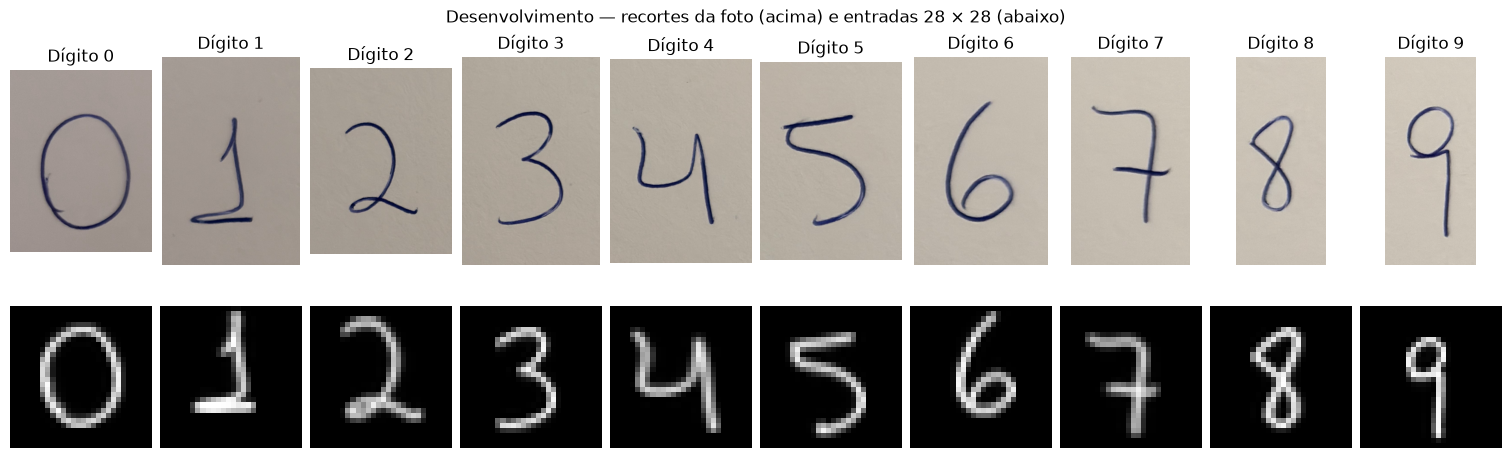

Formato para a CNN: (10, 28, 28, 1)


In [40]:
recortes_dev = []
for linha in manifesto_dev.itertuples(index=False):
    with Image.open(IMAGENS_PROPRIAS_DIR / linha.arquivo_foto) as foto:
        assert 0 <= linha.x0 < linha.x1 <= foto.width
        assert 0 <= linha.y0 < linha.y1 <= foto.height
        recortes_dev.append(foto.convert("RGB").crop((linha.x0, linha.y0, linha.x1, linha.y1)))

imagens_dev = np.stack([preparar_digito(recorte, **PARAMETROS_PREPROCESSAMENTO) for recorte in recortes_dev])
y_dev = manifesto_dev["rotulo"].to_numpy()
X_dev_cnn = imagens_dev[..., np.newaxis]
assert X_dev_cnn.shape == (10, 28, 28, 1)
assert X_dev_cnn.dtype == np.float32
assert 0 <= X_dev_cnn.min() <= X_dev_cnn.max() <= 1

fig, axes = plt.subplots(2, 10, figsize=(15, 4.8), layout="constrained")
for coluna, (recorte, processado, rotulo) in enumerate(zip(recortes_dev, imagens_dev, y_dev)):
    axes[0, coluna].imshow(recorte)
    axes[0, coluna].set_title(f"Dígito {rotulo}")
    axes[1, coluna].imshow(processado, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    axes[0, coluna].axis("off")
    axes[1, coluna].axis("off")
fig.suptitle("Desenvolvimento — recortes da foto (acima) e entradas 28 × 28 (abaixo)")
fig.savefig(FIGURES_DIR / "preprocessamento_desenvolvimento.png", dpi=150)
plt.show()
print("Formato para a CNN:", X_dev_cnn.shape)

**Conclusão do processamento.** Os dez recortes produziram imagens válidas de 28 × 28, com traços claros sobre fundo preto, valores finitos em [0, 1] e tipo `float32`. O lote resultante tem dimensão (10, 28, 28, 1), compatível com a CNN. A inspeção visual confirmou dígitos completos nos recortes e a manutenção de suas formas após o processamento. A normalização já está incluída na função; não se deve dividir novamente essas entradas por 255.

O resultado corresponde ao objetivo de adequar orientação, escala, contraste e posição das imagens ao formato do modelo. Essa adequação não elimina todas as diferenças entre fotografias próprias e MNIST, nem garante que o modelo reconheça cada estilo de escrita.

### Verificação nas dez imagens de desenvolvimento

Usamos a CNN completa selecionada na validação e a temperatura já fixada. Esses resultados servem para verificar a integração do processamento com o modelo e não constituem a avaliação final de imagens próprias. Registramos todas as previsões, inclusive os erros. As probabilidades referem-se às dez classes da CNN; o modelo reduzido do desafio anterior não é utilizado aqui.

In [41]:
logits_dev = obter_logits_cnn(X_dev_cnn)
probabilidades_dev = softmax(logits_dev / temperatura_cnn, axis=1)
previsoes_dev = probabilidades_dev.argmax(axis=1)
assert probabilidades_dev.shape == (10, 10)
assert np.isfinite(probabilidades_dev).all()
assert np.allclose(probabilidades_dev.sum(axis=1), 1)
resultados_dev = pd.DataFrame({
    "Imagem": manifesto_dev["id"].to_numpy(), "Verdadeiro": y_dev,
    "Previsto": previsoes_dev, "Confiança calibrada": probabilidades_dev.max(axis=1),
    "Acerto": previsoes_dev == y_dev,
})
resultados_dev.to_csv(TABLES_DIR / "imagens_proprias_desenvolvimento.csv", index=False)
configuracao_processamento = json.loads((IMAGENS_PROPRIAS_DIR / "preprocessamento.json").read_text(encoding="utf-8"))
assert configuracao_processamento["versao"] == "1.0"
assert configuracao_processamento["parametros"] == PARAMETROS_PREPROCESSAMENTO
print(f"Acertos no desenvolvimento: {int((previsoes_dev == y_dev).sum())}/10")
resultados_dev.round(4)

Acertos no desenvolvimento: 9/10


,Imagem,Verdadeiro,Previsto,Confiança calibrada,Acerto
0,dev_0,0,0,0.9925,True
1,dev_1,1,2,0.7536,False
2,dev_2,2,2,0.9998,True
3,dev_3,3,3,1.0000,True
4,dev_4,4,4,0.9998,True
5,dev_5,5,5,0.9953,True
6,dev_6,6,6,0.9994,True
7,dev_7,7,7,0.9997,True
8,dev_8,8,8,0.9999,True
9,dev_9,9,9,0.9994,True


**Conclusão do desenvolvimento com imagens próprias.** A CNN selecionada reconheceu corretamente nove dos dez dígitos da primeira foto. O dígito 1 foi previsto como 2, com confiança calibrada de 75,36%. Os demais dígitos tiveram previsões corretas, com confiança entre 99,25% e 100% quando arredondada. O erro foi preservado na tabela.

Esse resultado verifica o funcionamento da cadeia de processamento e inferência, mas não estima o desempenho final sobre imagens próprias: os dez exemplos foram usados no desenvolvimento do processamento. Os pesos da CNN e a temperatura não foram ajustados com essas imagens. As diferenças de escrita e representação podem contribuir para erros, mas esta observação isolada não permite atribuir a causa a um traço específico.

Os parâmetros do processamento foram registrados na versão 1.0 e mantidos para as vinte imagens reservadas das fotos `IMG_7058.heic` e `IMG_7059.heic`. Não foram realizados ajustes por dígito para eliminar o erro observado.

### Avaliação das vinte imagens reservadas

As fotografias `IMG_7058.heic` e `IMG_7059.heic` foram orientadas e convertidas para cópias PNG com o mesmo procedimento de preparação. Os recortes e rótulos foram registrados no manifesto antes da inferência. Aplicamos a função e os parâmetros da versão 1.0 definidos no desenvolvimento, sem ajustá-los por foto ou por dígito.

A CNN e a temperatura são as escolhidas com dados do MNIST. Esta avaliação contém duas imagens de cada classe e mede somente este pequeno conjunto de fotografias, de uma mesma pessoa. Os dez exemplos de desenvolvimento permanecem identificados separadamente.

In [42]:
manifesto_aval = manifesto_proprias.loc[manifesto_proprias["finalidade"] == "avaliacao"].sort_values(["fonte_original", "rotulo"]).reset_index(drop=True)
assert len(manifesto_proprias) == 30 and manifesto_proprias["id"].is_unique
assert len(manifesto_aval) == 20
assert set(manifesto_aval["fonte_original"]) == {"IMG_7058.heic", "IMG_7059.heic"}
assert set(manifesto_dev["fonte_original"]).isdisjoint(manifesto_aval["fonte_original"])
assert manifesto_aval.groupby("fonte_original")["rotulo"].apply(lambda rotulos: sorted(rotulos) == list(range(10))).all()
assert configuracao_processamento["parametros"] == PARAMETROS_PREPROCESSAMENTO

recortes_aval = []
for linha in manifesto_aval.itertuples(index=False):
    with Image.open(IMAGENS_PROPRIAS_DIR / linha.arquivo_foto) as foto:
        assert 0 <= linha.x0 < linha.x1 <= foto.width
        assert 0 <= linha.y0 < linha.y1 <= foto.height
        recortes_aval.append(foto.convert("RGB").crop((linha.x0, linha.y0, linha.x1, linha.y1)))
imagens_aval = np.stack([preparar_digito(recorte, **configuracao_processamento["parametros"]) for recorte in recortes_aval])
y_aval_proprias = manifesto_aval["rotulo"].to_numpy()
X_aval_proprias_cnn = imagens_aval[..., np.newaxis]
assert X_aval_proprias_cnn.shape == (20, 28, 28, 1)
assert X_aval_proprias_cnn.dtype == np.float32
assert np.isfinite(X_aval_proprias_cnn).all()
assert 0 <= X_aval_proprias_cnn.min() <= X_aval_proprias_cnn.max() <= 1
print("Imagens reservadas preparadas:", X_aval_proprias_cnn.shape)

Imagens reservadas preparadas: (20, 28, 28, 1)


In [43]:
logits_aval_proprias = obter_logits_cnn(X_aval_proprias_cnn)
probabilidades_aval_proprias = softmax(logits_aval_proprias / temperatura_cnn, axis=1)
previsoes_aval_proprias = probabilidades_aval_proprias.argmax(axis=1)
assert probabilidades_aval_proprias.shape == (20, 10)
assert np.isfinite(probabilidades_aval_proprias).all()
assert np.allclose(probabilidades_aval_proprias.sum(axis=1), 1)
assert np.array_equal(previsoes_aval_proprias, logits_aval_proprias.argmax(axis=1))

resultados_aval_proprias = pd.DataFrame({
    "Imagem": manifesto_aval["id"], "Foto": manifesto_aval["fonte_original"],
    "Verdadeiro": y_aval_proprias, "Previsto": previsoes_aval_proprias,
    "Confiança calibrada": probabilidades_aval_proprias.max(axis=1),
    "Acerto": previsoes_aval_proprias == y_aval_proprias,
})
resultados_aval_proprias.to_csv(TABLES_DIR / "imagens_proprias_avaliacao.csv", index=False)
resumo_aval_proprias = resultados_aval_proprias.groupby("Foto").agg(
    Imagens=("Acerto", "size"), Acertos=("Acerto", "sum"), Acuracia=("Acerto", "mean"),
)
resumo_aval_proprias.to_csv(TABLES_DIR / "resumo_imagens_proprias.csv")
print(f"Acertos nas imagens reservadas: {int(resultados_aval_proprias['Acerto'].sum())}/20")
display(resumo_aval_proprias.round(4))
resultados_aval_proprias.round(4)

Acertos nas imagens reservadas: 20/20


,Imagens,Acertos,Acuracia
Foto,,,
IMG_7058.heic,10,10,1.0
IMG_7059.heic,10,10,1.0


,Imagem,Foto,Verdadeiro,Previsto,Confiança calibrada,Acerto
0,aval_7058_0,IMG_7058.heic,0,0,0.9964,True
1,aval_7058_1,IMG_7058.heic,1,1,0.9720,True
2,aval_7058_2,IMG_7058.heic,2,2,0.9851,True
3,aval_7058_3,IMG_7058.heic,3,3,0.9997,True
4,aval_7058_4,IMG_7058.heic,4,4,0.9953,True
5,aval_7058_5,IMG_7058.heic,5,5,0.9896,True
6,aval_7058_6,IMG_7058.heic,6,6,0.9887,True
7,aval_7058_7,IMG_7058.heic,7,7,0.9749,True
8,aval_7058_8,IMG_7058.heic,8,8,0.9913,True
9,aval_7058_9,IMG_7058.heic,9,9,0.9999,True


**Conclusão da avaliação das imagens próprias.** As vinte imagens reservadas atenderam ao formato esperado pela CNN, com os mesmos parâmetros de processamento definidos no desenvolvimento. Houve 20 acertos em 20 imagens (100%): 10/10 na foto `IMG_7058.heic` e 10/10 na foto `IMG_7059.heic`. Não houve erro neste conjunto. Os pesos da CNN, a temperatura e os parâmetros do processamento foram mantidos após observar esse resultado.

A taxa de 100% descreve este conjunto de vinte exemplos, de uma mesma pessoa e provenientes de duas fotografias. Um resultado sem erros em vinte imagens não significa ausência de erro: cada exemplo a mais ou a menos valeria cinco pontos percentuais, e as imagens compartilham condições de captura. Portanto, o resultado não sustenta uma estimativa precisa de desempenho para outras pessoas ou fotografias, e seria imprudente lê-lo como 100% de acerto esperado. Os 9/10 acertos do desenvolvimento são apresentados separadamente, pois esses exemplos participaram da definição do processamento.

A dispersão das confianças mostra que a transformação de temperatura ajustada no MNIST não produz probabilidades uniformemente altas nas fotografias próprias. O dígito 9 da segunda foto foi reconhecido corretamente, mas com a menor confiança do conjunto, 69,43%; o dígito 2 da mesma foto veio em seguida, com 74,27%. Ou seja, o acerto em vinte imagens convive com casos em que o modelo esteve longe da certeza, e a margem nesses casos é estreita. Confiança é a probabilidade atribuída pelo modelo à classe escolhida; a confirmação de acerto exige comparar a previsão com o rótulo verdadeiro.

**Luminosidade.** A iluminação pode alterar o contraste e a representação dos traços que chegam ao modelo. O processamento estima o fundo para reduzir essa influência, mas o experimento não isolou o fator iluminação. Portanto, não é possível atribuir à luminosidade nem o erro observado no desenvolvimento nem as confianças mais baixas da segunda foto. Para testar essa hipótese, seria necessário fotografar os mesmos dígitos sob condições de luz controladas, mantendo os demais fatores tão constantes quanto possível, com repetições e o mesmo processamento.

### Dígitos e probabilidades — todas as trinta imagens

Cada painel apresenta a imagem processada, seu rótulo verdadeiro, a previsão e as dez probabilidades. A barra azul identifica a classe prevista. Os títulos indicam acerto ou erro e identificam a finalidade de cada foto. As probabilidades usam a temperatura ajustada no MNIST; isso não garante calibração adequada nas fotografias próprias.

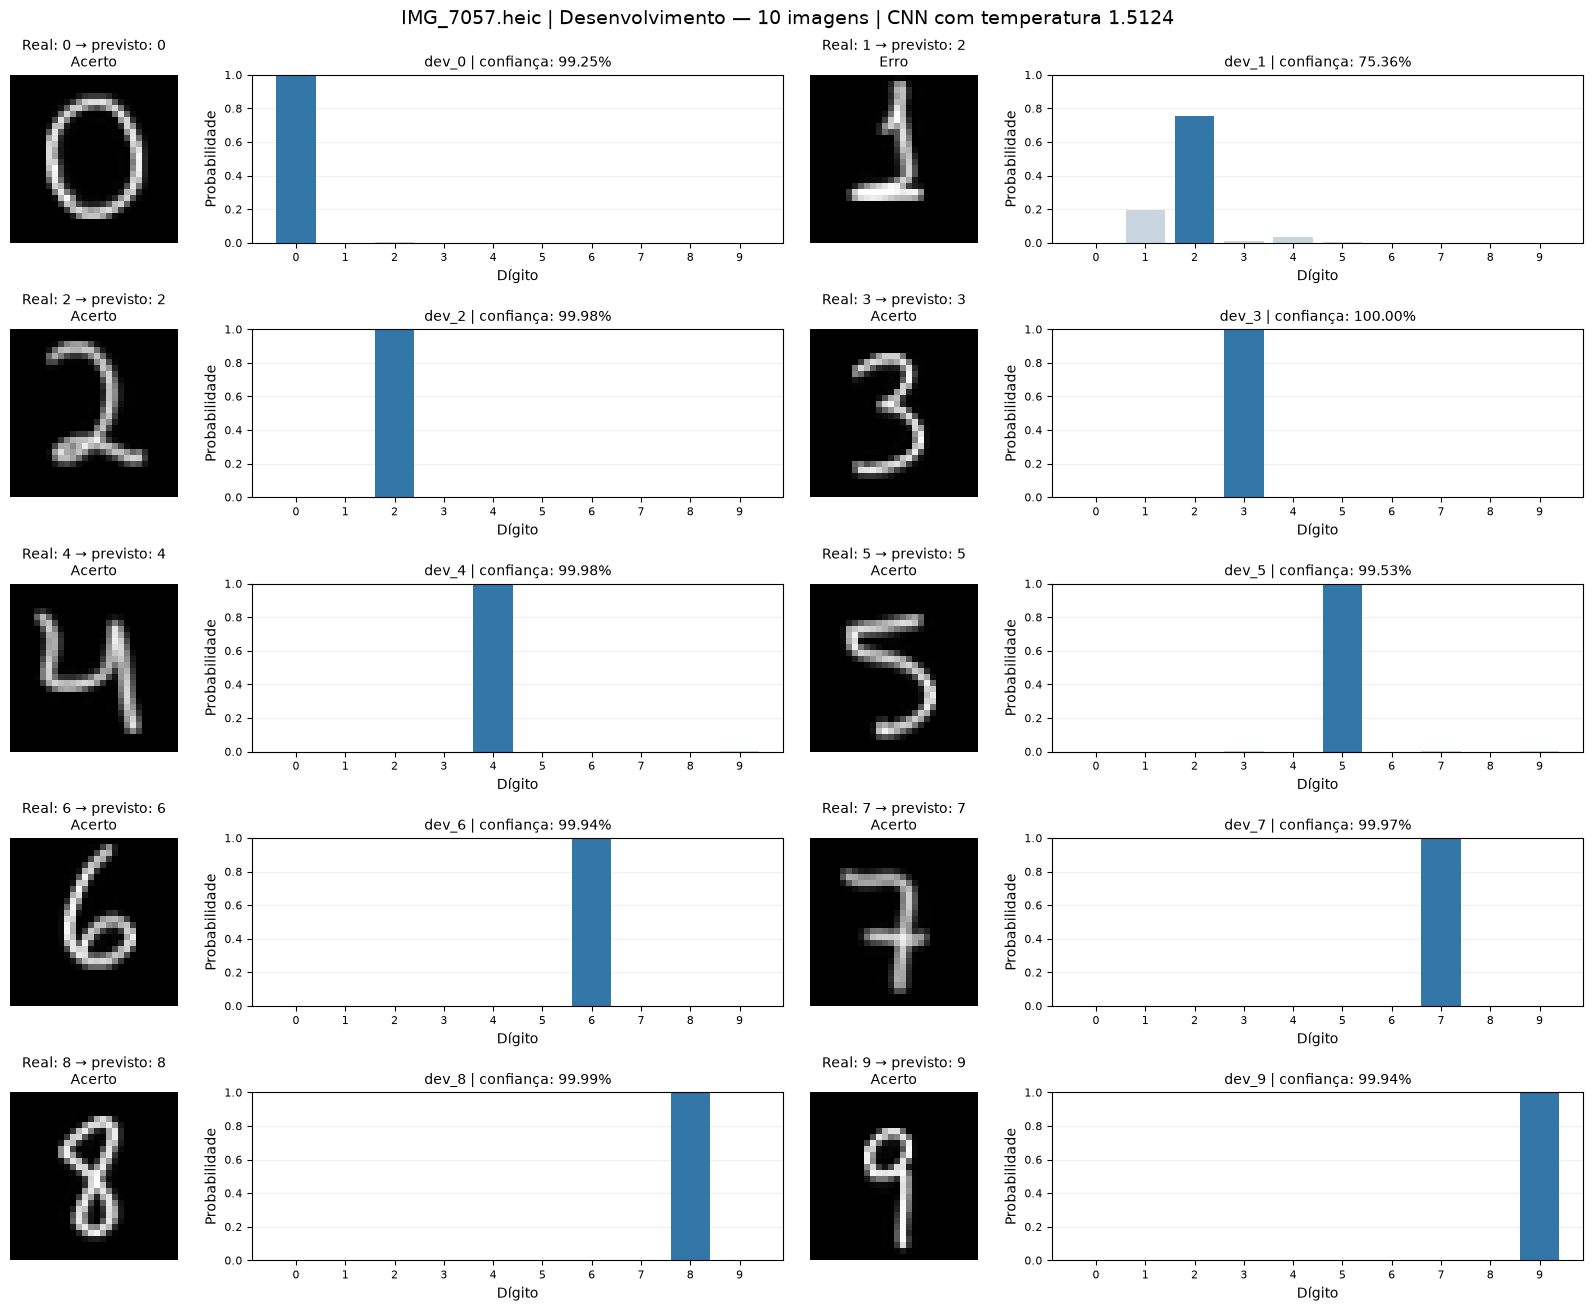

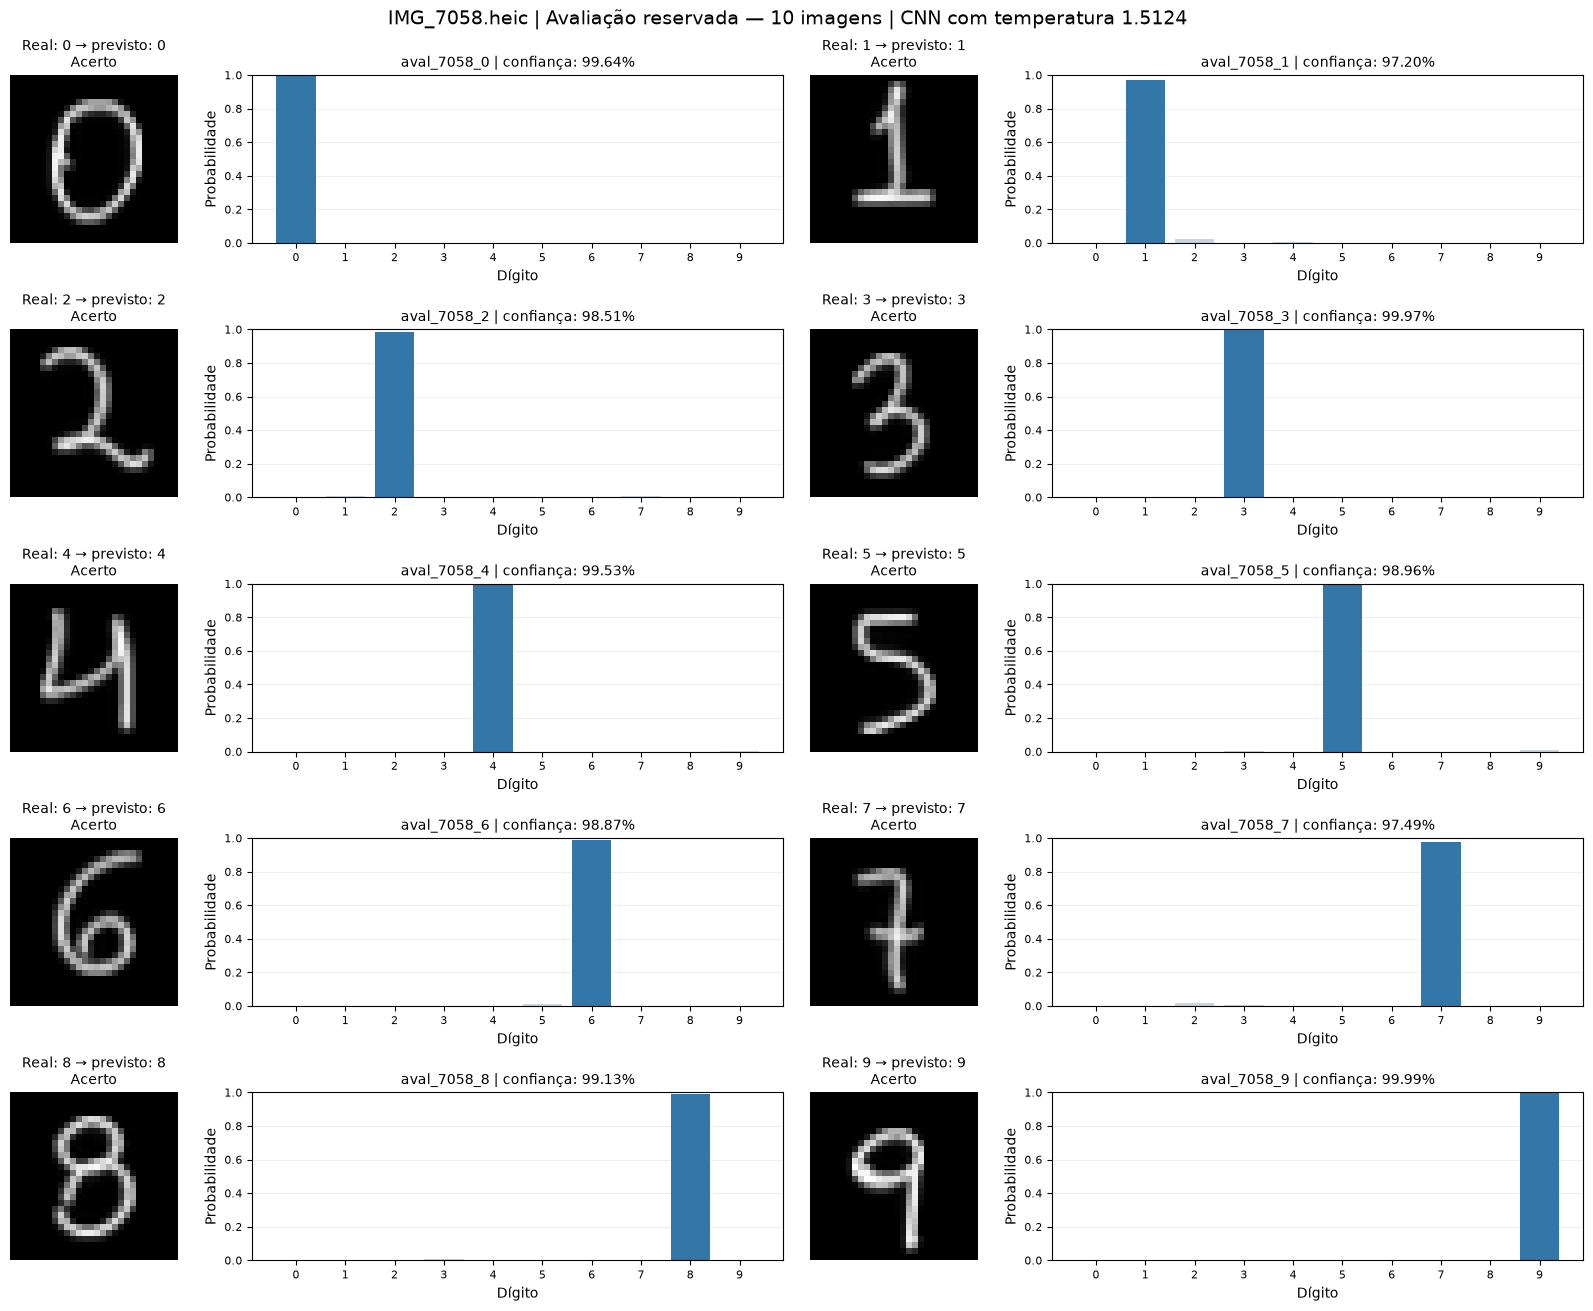

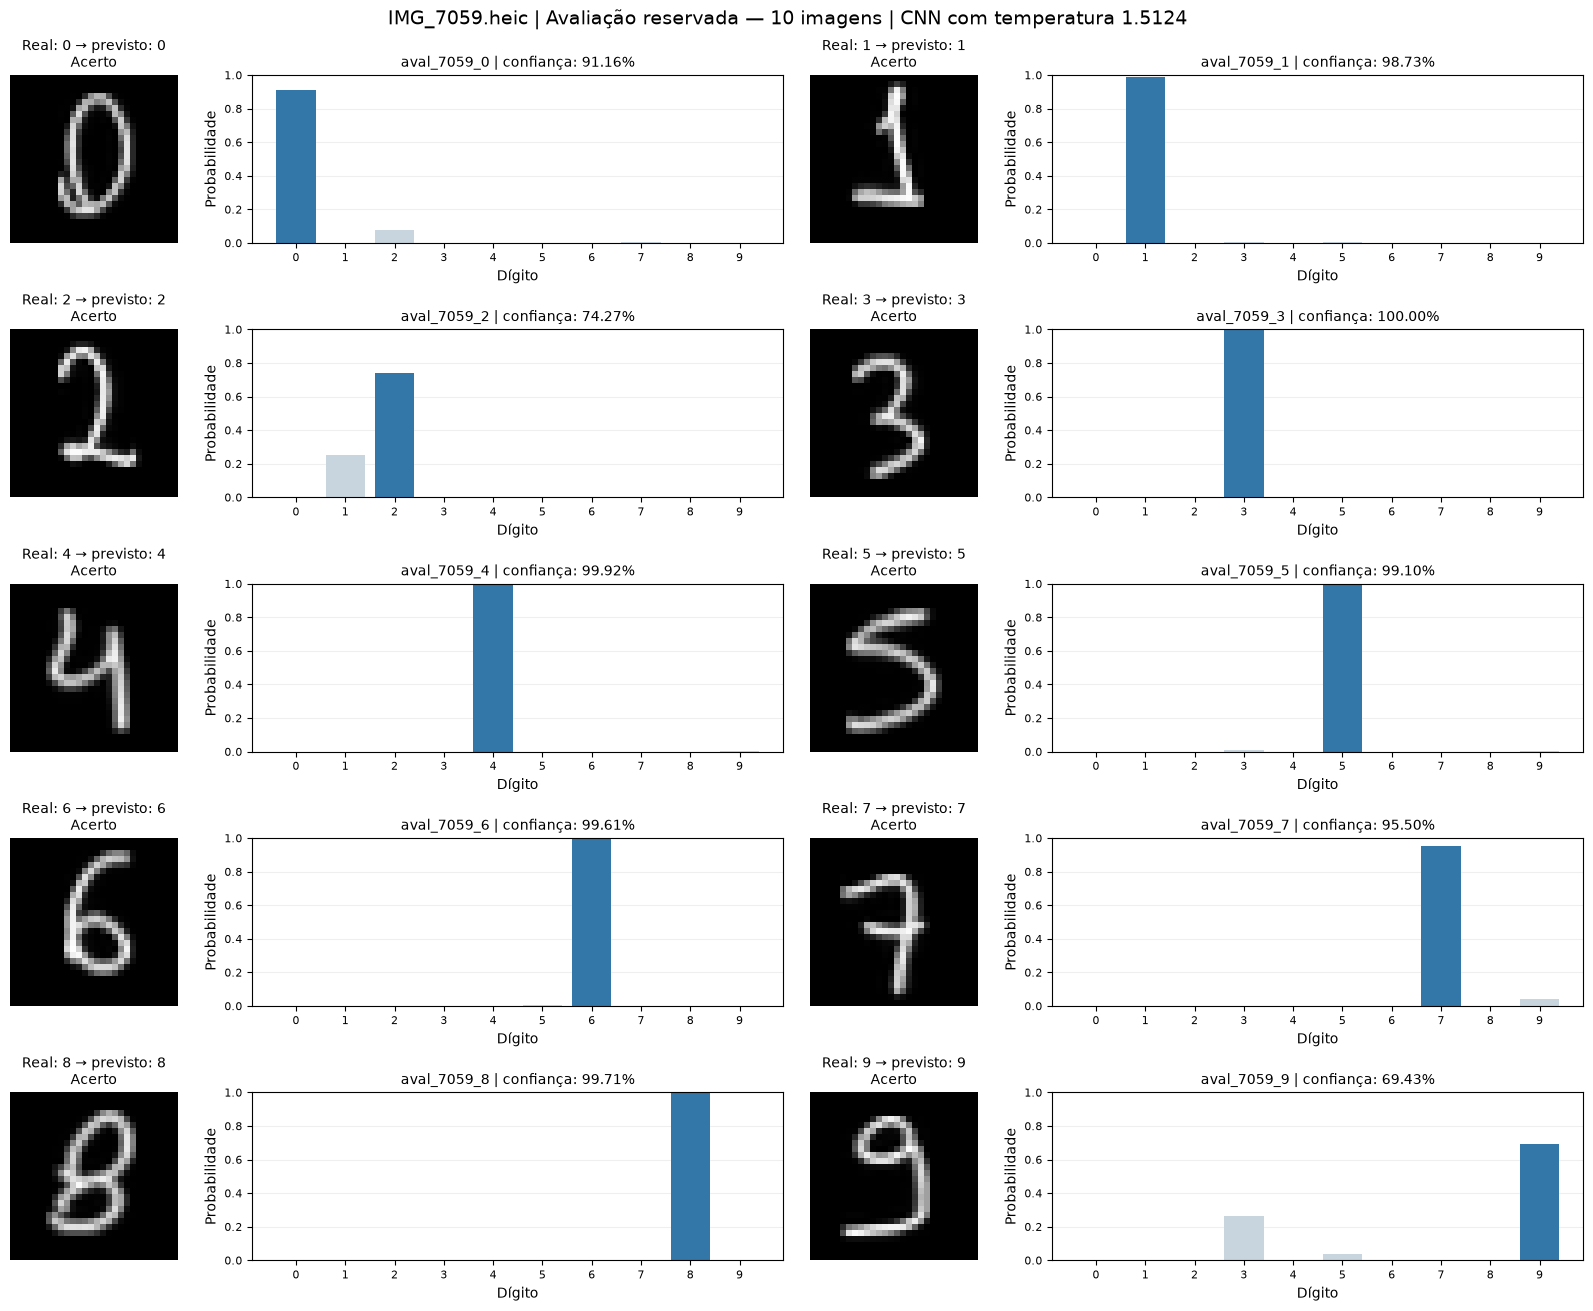

In [44]:
manifesto_galeria = pd.concat([manifesto_dev, manifesto_aval], ignore_index=True)
imagens_galeria = np.concatenate([imagens_dev, imagens_aval])
probabilidades_galeria = np.concatenate([probabilidades_dev, probabilidades_aval_proprias])
assert len(manifesto_galeria) == len(imagens_galeria) == len(probabilidades_galeria) == 30

for fonte, grupo in manifesto_galeria.groupby("fonte_original", sort=False):
    fig, axes = plt.subplots(5, 4, figsize=(16, 13), gridspec_kw={"width_ratios": [1, 2.6, 1, 2.6]}, layout="constrained")
    for posicao, (indice, linha) in enumerate(grupo.iterrows()):
        fila, par = divmod(posicao, 2)
        ax_imagem, ax_prob = axes[fila, par * 2], axes[fila, par * 2 + 1]
        probs = probabilidades_galeria[indice]
        previsto = int(probs.argmax())
        verdadeiro = int(linha["rotulo"])
        estado = "Acerto" if previsto == verdadeiro else "Erro"
        ax_imagem.imshow(imagens_galeria[indice], cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        ax_imagem.set_title(f"Real: {verdadeiro} → previsto: {previsto}\n{estado}", fontsize=10)
        ax_imagem.axis("off")
        cores = ["#3277A8" if digito == previsto else "#C9D5DE" for digito in range(10)]
        ax_prob.bar(range(10), probs, color=cores)
        ax_prob.set(title=f"{linha['id']} | confiança: {probs[previsto]:.2%}",
                    xlabel="Dígito", ylabel="Probabilidade", ylim=(0, 1), xticks=range(10))
        ax_prob.title.set_fontsize(10)
        ax_prob.tick_params(labelsize=8)
        ax_prob.grid(axis="y", alpha=0.2)
        ax_prob.set_axisbelow(True)
    finalidade = "Desenvolvimento — 10 imagens" if grupo.iloc[0]["finalidade"] == "desenvolvimento" else "Avaliação reservada — 10 imagens"
    fig.suptitle(f"{fonte} | {finalidade} | CNN com temperatura {temperatura_cnn:.4f}", fontsize=14)
    fig.savefig(FIGURES_DIR / f"probabilidades_{Path(fonte).stem}.png", dpi=150)
    plt.show()

registro_probabilidades = manifesto_galeria[["id", "fonte_original", "finalidade", "rotulo"]].copy()
for digito in range(10):
    registro_probabilidades[f"P({digito})"] = probabilidades_galeria[:, digito]
registro_probabilidades.to_csv(TABLES_DIR / "probabilidades_imagens_proprias.csv", index=False)

**Conclusão das probabilidades por imagem.** As três galerias apresentam todos os trinta dígitos, com as dez probabilidades, a classe prevista e a indicação de acerto ou erro. As barras usam a mesma escala de 0 a 1, permitindo comparar a concentração das probabilidades entre exemplos. A tabela exportada preserva os valores numéricos e a identificação da fotografia e da finalidade de cada imagem.

O experimento demonstra que a CNN treinada no MNIST consegue reconhecer a maioria dos exemplos deste conjunto próprio após o processamento, mas ainda comete erros, inclusive com alta confiança. A imagem processada e sua previsão permitem inspecionar esses casos; não permitem, isoladamente, identificar a causa do erro. Uma investigação posterior poderia usar novos dados para avaliar outras condições de escrita e captura, mantendo uma nova amostra reservada para verificar eventuais ajustes.

### Inspeção do processamento por etapas

Os painéis expõem as transformações da mesma função que prepara a entrada da CNN, implementada em [mnist_demo/preprocessamento.py](mnist_demo/preprocessamento.py). Apresentamos o dígito 1 de desenvolvimento, o 8 de desenvolvimento e o 9 da segunda fotografia de avaliação. Os exemplos foram escolhidos para inspecionar formas e erros já registrados; não constituem uma amostra representativa nem um novo ajuste.

A imagem em cinza preserva a iluminação capturada; o contraste relativo usa uma estimativa suave do fundo; a máscara destaca os componentes do traço; a última coluna mostra a entrada efetivamente classificada. A normalização já está incluída.

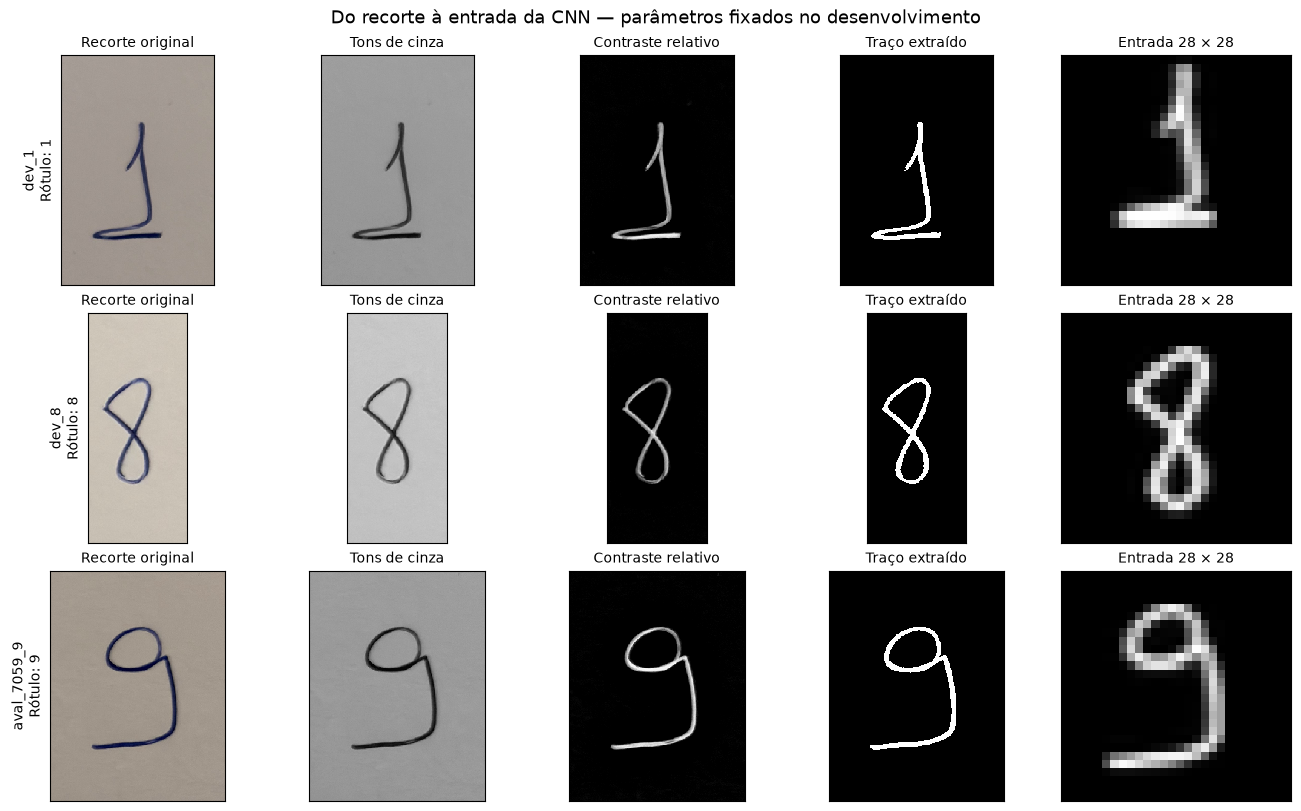

In [45]:
ids_inspecao = ["dev_1", "dev_8", "aval_7059_9"]
fig, axes = plt.subplots(len(ids_inspecao), 5, figsize=(13, 8), layout="constrained")
titulos = ["Recorte original", "Tons de cinza", "Contraste relativo", "Traço extraído", "Entrada 28 × 28"]
for fila, identificador in enumerate(ids_inspecao):
    linha = manifesto_proprias.set_index("id").loc[identificador]
    with Image.open(IMAGENS_PROPRIAS_DIR / linha["arquivo_foto"]) as foto:
        recorte = foto.convert("RGB").crop(tuple(int(linha[c]) for c in ["x0", "y0", "x1", "y1"]))
    etapas = etapas_digito(recorte, **PARAMETROS_PREPROCESSAMENTO)
    indice = manifesto_galeria.index[manifesto_galeria["id"] == identificador][0]
    assert np.array_equal(etapas["entrada"], imagens_galeria[indice])
    paineis = [recorte, etapas["cinza"], etapas["contraste"], etapas["traco"], etapas["entrada"]]
    for coluna, painel in enumerate(paineis):
        ax = axes[fila, coluna]
        ax.imshow(painel, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
        ax.set_title(titulos[coluna], fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
    axes[fila, 0].set_ylabel(f"{identificador}\nRótulo: {linha['rotulo']}", fontsize=10)
fig.suptitle("Do recorte à entrada da CNN — parâmetros fixados no desenvolvimento", fontsize=13)
fig.savefig(FIGURES_DIR / "etapas_processamento.png", dpi=150)
plt.show()

**Conclusão da inspeção.** As entradas exibidas na última coluna são idênticas às utilizadas nas previsões já registradas. A extração da função para um módulo compartilhado também preservou exatamente os pixels processados dos trinta recortes. Os painéis permitem observar como fundo e traço são representados, sem alterar os parâmetros do experimento.

O erro no 9 continua registrado mesmo após a visualização das etapas. A comparação não isola a influência da iluminação e não identifica sozinha a causa do erro. A extração e a redução mudam a representação da escrita; atribuir um efeito específico exige um experimento controlado.

## 9. Conclusão geral e possibilidades de melhoria

A CNN apresentou o maior F1 ponderado na validação e manteve essa posição no teste independente: F1 de 0,989933 e acurácia de 98,9929%, com 13.859 acertos em 14.000 imagens. A MLP foi a melhor entre as três famílias principais. O bootstrap pareado estimou uma diferença de F1 CNN − MLP de 0,013382, com intervalo de 95% [0,011304; 0,015602], condicionado aos modelos já ajustados. A vantagem observada da CNN veio acompanhada de maior tempo de ajuste entre as configurações selecionadas; os tempos são específicos desta execução.

A classificação correta e a qualidade das probabilidades exigem avaliações distintas. A temperatura ajustada na calibração preservou as classes previstas e melhorou log loss e ECE no teste, o que indica que a CNN era superconfiante antes do ajuste e que a correção estimada em um conjunto separado transferiu para dados não vistos. O experimento com classes ocultadas produziu 106 erros com confiança de pelo menos 90%, mostrando que um classificador de conjunto fechado pode atribuir alta probabilidade a uma alternativa incorreta sem reconhecer a ausência da classe verdadeira.

Nas imagens próprias, a CNN acertou os 20 exemplos reservados, após processamento definido em outros dez exemplos. Ainda assim, a confiança variou bastante entre eles: o dígito 9 da segunda foto foi reconhecido com 69,43%, e no conjunto de desenvolvimento permanece um dígito 1 previsto como 2 com 75,36%. Esse resultado é restrito à pequena amostra de uma pessoa e duas fotografias, e o acerto integral nas vinte imagens não deve ser lido como ausência de erro. As diferenças de escrita, iluminação e representação são hipóteses para investigação; o desenho realizado não separa seus efeitos.

Como melhorias futuras, propomos ampliar a avaliação com outras pessoas e condições de captura; testar iluminação de forma controlada; estudar aumento de dados usando apenas treino e validação; e avaliar um mecanismo de rejeição com exemplos conhecidos e desconhecidos. Eventuais decisões de ajuste exigem novos dados de desenvolvimento e uma nova amostra reservada. Os resultados atuais permanecem registrados, inclusive as limitações e os erros.